In [1]:
# Cell 1: Environment Setup, Imports & Reproducibility

from pathlib import Path
import json
import os
import shutil
import sys
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from scipy.ndimage import gaussian_filter1d
from scipy.signal import butter, filtfilt, find_peaks, medfilt
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

from sklearn.utils.class_weight import compute_class_weight

SEED = 42
tf.keras.utils.set_random_seed(SEED)
plt.rcParams.update({
    "figure.figsize": (12, 5),
    "figure.dpi": 100,
    "axes.grid": False,
})
print("=" * 75)
print("ECG DEEP LEARNING ENVIRONMENT")
print("=" * 75)
print(f"Python      : {sys.version.split()[0]}")
print(f"TensorFlow  : {tf.__version__}")
print(f"OpenCV      : {cv2.__version__}")
print(f"NumPy       : {np.__version__}")
print(f"Pandas      : {pd.__version__}")
print(f"Random Seed : {SEED}")
print("=" * 75)
print("✓ Imports loaded successfully")
print("✓ Reproducibility seed configured")
print("=" * 75)

ECG DEEP LEARNING ENVIRONMENT
Python      : 3.12.13
TensorFlow  : 2.20.0
OpenCV      : 4.13.0
NumPy       : 2.0.2
Pandas      : 2.3.3
Random Seed : 42
✓ Imports loaded successfully
✓ Reproducibility seed configured


In [2]:
# Cell 2: Configuration & ECG Calibration Parameters

from pathlib import Path

INPUT_IMAGE_PATH = Path(
    "/kaggle/input/datasets/ranesh2409/full-ecg-binary-classification/Abnormal/Abnormal_010.jpg"
)

OUTPUT_DIR = Path("/kaggle/working/ECG_Pipeline_Output")
INTERMEDIATE_DIR = OUTPUT_DIR / "intermediate"
TRIMMED_DIR = INTERMEDIATE_DIR / "trimmed_signals"
PEAK_DIR = INTERMEDIATE_DIR / "r_peaks"
BEAT_DIR = OUTPUT_DIR / "extracted_beats"

OUTPUT_PATHS = [
    OUTPUT_DIR,
    INTERMEDIATE_DIR,
    TRIMMED_DIR,
    PEAK_DIR,
    BEAT_DIR,
]

for path in OUTPUT_PATHS:
    path.mkdir(parents=True, exist_ok=True)

ECG_SPEED_MM_PER_SEC = 25.0
ECG_GAIN_MM_PER_MV = 10.0

PRE_R_SEC = 0.25
POST_R_SEC = 0.45
TOTAL_WINDOW_SEC = PRE_R_SEC + POST_R_SEC

PRE_SAMPLES = 70
POST_SAMPLES = 110
BEAT_LENGTH = PRE_SAMPLES + POST_SAMPLES

EFFECTIVE_FS = BEAT_LENGTH / TOTAL_WINDOW_SEC

if ECG_SPEED_MM_PER_SEC <= 0:
    raise ValueError("ECG_SPEED_MM_PER_SEC must be greater than zero.")

if ECG_GAIN_MM_PER_MV <= 0:
    raise ValueError("ECG_GAIN_MM_PER_MV must be greater than zero.")

if PRE_R_SEC <= 0 or POST_R_SEC <= 0:
    raise ValueError("PRE_R_SEC and POST_R_SEC must be greater than zero.")

if PRE_SAMPLES <= 0 or POST_SAMPLES <= 0:
    raise ValueError("PRE_SAMPLES and POST_SAMPLES must be greater than zero.")

if not INPUT_IMAGE_PATH.exists():
    print(f"Warning: Input ECG image not found: {INPUT_IMAGE_PATH}")

print("Configuration initialized successfully.")
print(f"Input ECG: {INPUT_IMAGE_PATH}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"ECG calibration: {ECG_SPEED_MM_PER_SEC} mm/s, {ECG_GAIN_MM_PER_MV} mm/mV")
print(f"Beat window: -{PRE_R_SEC:.2f}s to +{POST_R_SEC:.2f}s")
print(f"Beat samples: {PRE_SAMPLES} + {POST_SAMPLES} = {BEAT_LENGTH}")
print(f"Effective sampling rate: {EFFECTIVE_FS:.1f} Hz")

Configuration initialized successfully.
Input ECG: /kaggle/input/datasets/ranesh2409/full-ecg-binary-classification/Abnormal/Abnormal_010.jpg
Output directory: /kaggle/working/ECG_Pipeline_Output
ECG calibration: 25.0 mm/s, 10.0 mm/mV
Beat window: -0.25s to +0.45s
Beat samples: 70 + 110 = 180
Effective sampling rate: 257.1 Hz


ECG report loaded successfully | Dimensions: 2213 × 1572 px | Channels: 3


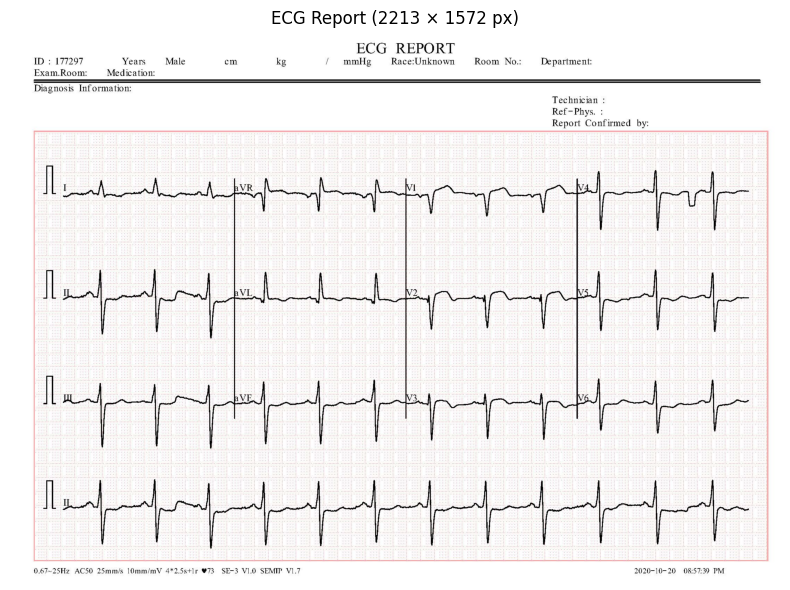

In [3]:
# Cell 3: Load, Validate, & Display ECG Report

def load_ecg_report(image_path: Path) -> tuple[np.ndarray, np.ndarray]:
    if not image_path.exists():
        raise FileNotFoundError(
            f"ECG report not found: {image_path}"
        )

    img_bgr = cv2.imread(str(image_path), cv2.IMREAD_COLOR)

    if img_bgr is None:
        raise ValueError(
            f"OpenCV failed to decode ECG report: {image_path}"
        )

    if img_bgr.size == 0:
        raise ValueError(
            f"Loaded ECG report is empty: {image_path}"
        )

    if img_bgr.ndim != 3 or img_bgr.shape[2] != 3:
        raise ValueError(
            f"Expected a 3-channel BGR image, got shape {img_bgr.shape}"
        )

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    if img_rgb.ndim != 3 or img_rgb.shape[2] != 3:
        raise ValueError(
            f"RGB conversion failed, got shape {img_rgb.shape}"
        )

    return img_bgr, img_rgb


ecg_bgr, ecg_rgb = load_ecg_report(INPUT_IMAGE_PATH)

height, width, channels = ecg_rgb.shape

print(
    f"ECG report loaded successfully | "
    f"Dimensions: {width} × {height} px | "
    f"Channels: {channels}"
)

plt.figure(figsize=(12, 6))
plt.imshow(ecg_rgb)
plt.title(f"ECG Report ({width} × {height} px)")
plt.axis("off")
plt.tight_layout()
plt.show()

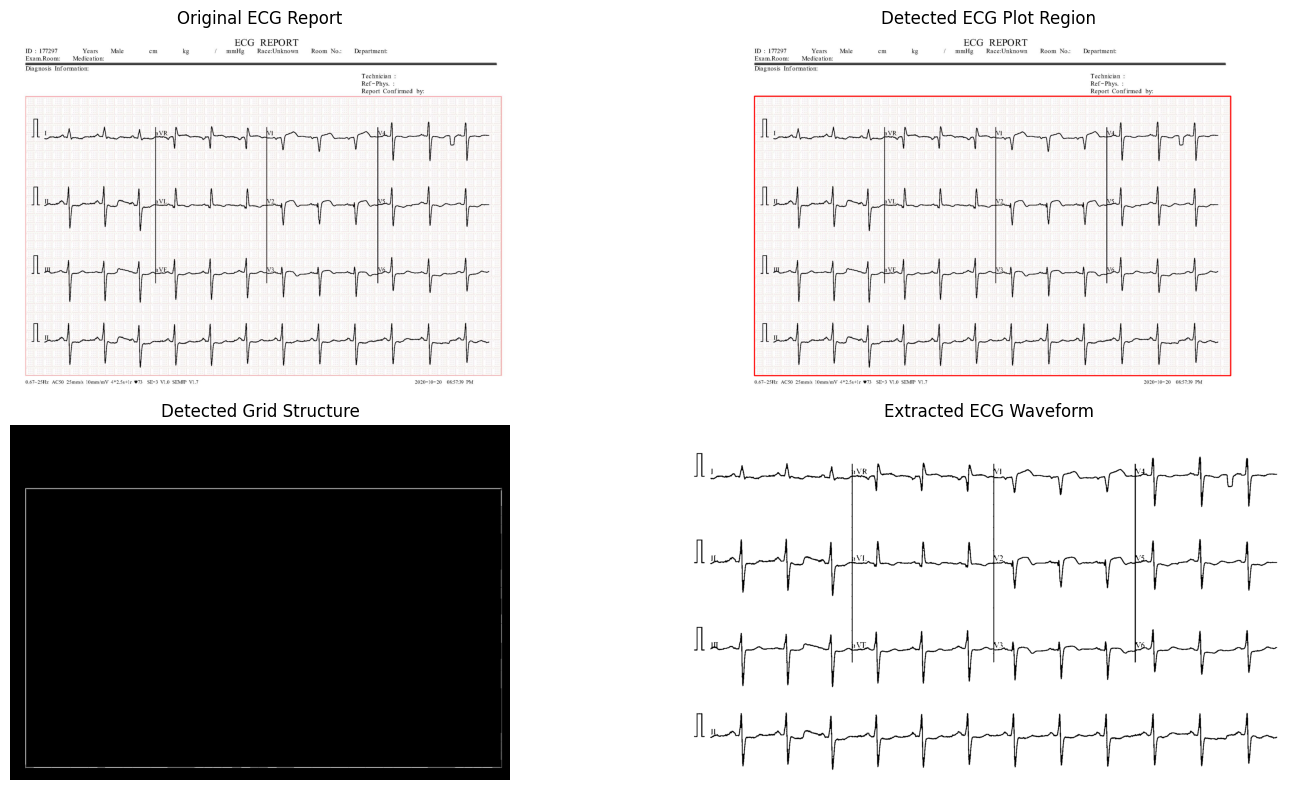

ECG plot region: x=68, y=283, width=2109, height=1235
ROI shape: (1235, 2109, 3)
Waveform mask shape: (1235, 2109)
Detected waveform pixels: 86,798
Waveform pixel ratio: 3.33%


In [4]:
# Cell 4: ECG Plot Detection + Robust Waveform Ink Extraction

def extract_ecg_plot_region_smart(
    img_rgb: np.ndarray,
) -> tuple[np.ndarray, tuple[int, int, int, int], np.ndarray]:

    h, w, _ = img_rgb.shape
    hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)

    saturation = hsv[:, :, 1]
    value = hsv[:, :, 2]

    grid_mask = (
        (saturation > 10)
        & (value > 100)
        & (value < 255)
    ).astype(np.uint8) * 255

    k_len = max(15, int(min(h, w) * 0.025))

    kernel_h = cv2.getStructuringElement(
        cv2.MORPH_RECT,
        (k_len, 1)
    )

    kernel_v = cv2.getStructuringElement(
        cv2.MORPH_RECT,
        (1, k_len)
    )

    horizontal_grid = cv2.morphologyEx(
        grid_mask,
        cv2.MORPH_OPEN,
        kernel_h
    )

    vertical_grid = cv2.morphologyEx(
        grid_mask,
        cv2.MORPH_OPEN,
        kernel_v
    )

    detected_grid = cv2.bitwise_or(
        horizontal_grid,
        vertical_grid
    )

    grid_density = np.mean(detected_grid > 0)

    if grid_density > 0.80:
        detected_grid = grid_mask

    proj_y = np.sum(detected_grid > 0, axis=1)
    proj_x = np.sum(detected_grid > 0, axis=0)

    y_threshold = proj_y.max() * 0.10 if proj_y.max() > 0 else 0
    x_threshold = proj_x.max() * 0.10 if proj_x.max() > 0 else 0

    y_indices = np.where(proj_y > y_threshold)[0]
    x_indices = np.where(proj_x > x_threshold)[0]

    if len(y_indices) > 0 and len(x_indices) > 0:
        ymin = int(y_indices[0])
        ymax = int(y_indices[-1]) + 1
        xmin = int(x_indices[0])
        xmax = int(x_indices[-1]) + 1
    else:
        xmin = int(w * 0.02)
        xmax = int(w * 0.98)
        ymin = int(h * 0.10)
        ymax = int(h * 0.92)

    xmin = max(0, min(xmin, w - 1))
    xmax = max(xmin + 1, min(xmax, w))

    ymin = max(0, min(ymin, h - 1))
    ymax = max(ymin + 1, min(ymax, h))

    cropped_roi = img_rgb[ymin:ymax, xmin:xmax]

    crop_box = (
        xmin,
        ymin,
        xmax - xmin,
        ymax - ymin
    )

    return cropped_roi, crop_box, detected_grid


def remove_grid_preserve_waveform(
    roi_rgb: np.ndarray
) -> np.ndarray:

    gray = cv2.cvtColor(
        roi_rgb,
        cv2.COLOR_RGB2GRAY
    )

    hsv = cv2.cvtColor(
        roi_rgb,
        cv2.COLOR_RGB2HSV
    )

    saturation = hsv[:, :, 1]

    otsu_thresh, _ = cv2.threshold(
        gray,
        0,
        255,
        cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    adaptive_threshold = max(
        100,
        min(190, int(otsu_thresh + 10))
    )

    dark_ink = gray < adaptive_threshold

    colored_structure = (
        (saturation > 35)
        & (gray > 100)
    )

    waveform_mask = (
        dark_ink
        & (~colored_structure)
    )

    binary = (
        waveform_mask.astype(np.uint8)
        * 255
    )

    denoise_kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (2, 2)
    )

    binary = cv2.morphologyEx(
        binary,
        cv2.MORPH_OPEN,
        denoise_kernel
    )

    reconnect_kernel = cv2.getStructuringElement(
        cv2.MORPH_RECT,
        (3, 1)
    )

    binary = cv2.morphologyEx(
        binary,
        cv2.MORPH_CLOSE,
        reconnect_kernel
    )

    clean_binary = np.full(
        binary.shape,
        255,
        dtype=np.uint8
    )

    clean_binary[binary > 0] = 0

    return clean_binary


ecg_roi, crop_box, grid_mask = extract_ecg_plot_region_smart(
    ecg_rgb
)

clean_waveform = remove_grid_preserve_waveform(
    ecg_roi
)

x, y, roi_width, roi_height = crop_box

annotated = ecg_rgb.copy()

cv2.rectangle(
    annotated,
    (x, y),
    (
        x + roi_width - 1,
        y + roi_height - 1
    ),
    (255, 0, 0),
    3
)

plot_region_output_path = (
    INTERMEDIATE_DIR /
    "cell_04_ecg_plot_region.png"
)

waveform_output_path = (
    INTERMEDIATE_DIR /
    "cell_04_clean_waveform.png"
)

cv2.imwrite(
    str(plot_region_output_path),
    cv2.cvtColor(
        ecg_roi,
        cv2.COLOR_RGB2BGR
    )
)

cv2.imwrite(
    str(waveform_output_path),
    clean_waveform
)

waveform_pixel_count = np.count_nonzero(
    clean_waveform == 0
)

total_pixels = clean_waveform.size

waveform_ratio = (
    waveform_pixel_count /
    total_pixels
)

if waveform_ratio < 0.001:
    raise ValueError(
        f"Very few ECG waveform pixels detected "
        f"({waveform_ratio:.4%}). "
        "Check the ECG crop or threshold parameters."
    )

if waveform_ratio > 0.40:
    raise ValueError(
        f"Too many pixels detected as waveform "
        f"({waveform_ratio:.2%}). "
        "Grid/background removal may have failed."
    )

plt.figure(figsize=(16, 8))

plt.subplot(2, 2, 1)
plt.imshow(ecg_rgb)
plt.title("Original ECG Report")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(annotated)
plt.title("Detected ECG Plot Region")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(grid_mask, cmap="gray")
plt.title("Detected Grid Structure")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(clean_waveform, cmap="gray")
plt.title("Extracted ECG Waveform")
plt.axis("off")

plt.tight_layout()
plt.show()

print(
    f"ECG plot region: "
    f"x={x}, y={y}, "
    f"width={roi_width}, height={roi_height}"
)

print(f"ROI shape: {ecg_roi.shape}")
print(f"Waveform mask shape: {clean_waveform.shape}")
print(
    f"Detected waveform pixels: "
    f"{waveform_pixel_count:,}"
)

print(
    f"Waveform pixel ratio: "
    f"{waveform_ratio:.2%}"
)

ECG ROI: 2109 × 1235 | Rows prepared: 4


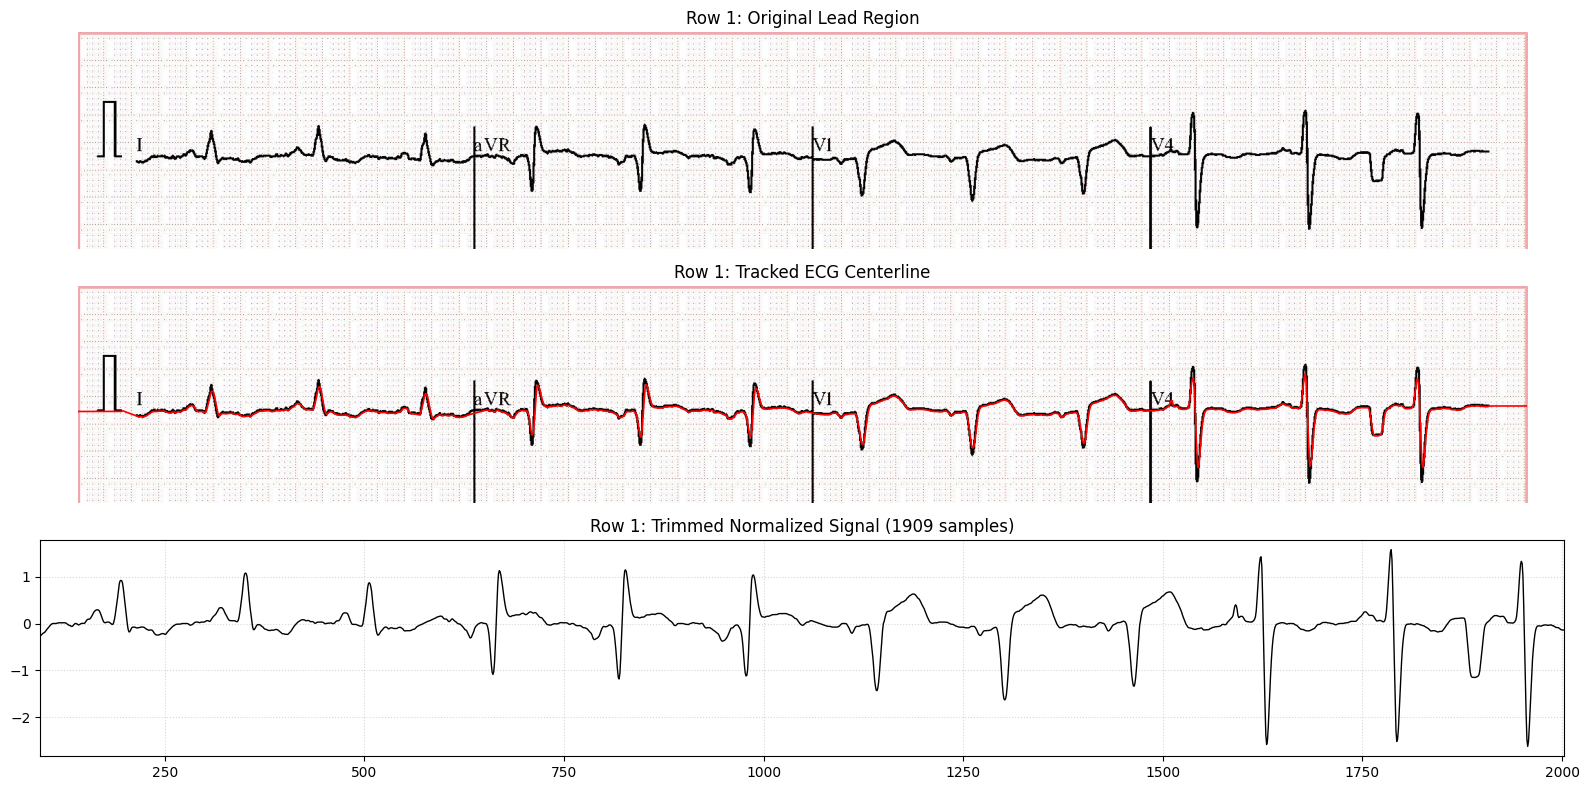

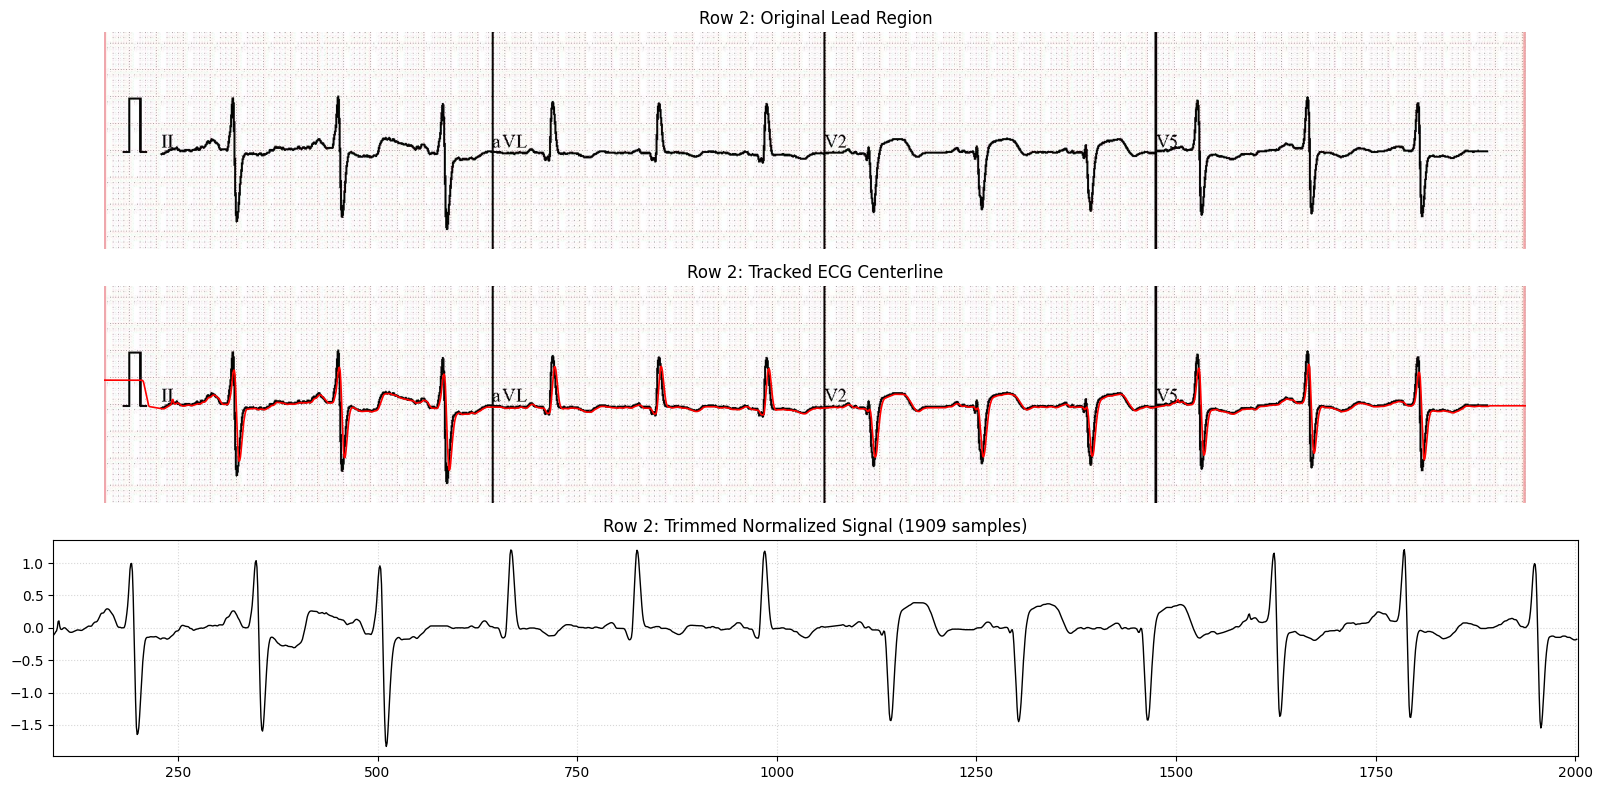

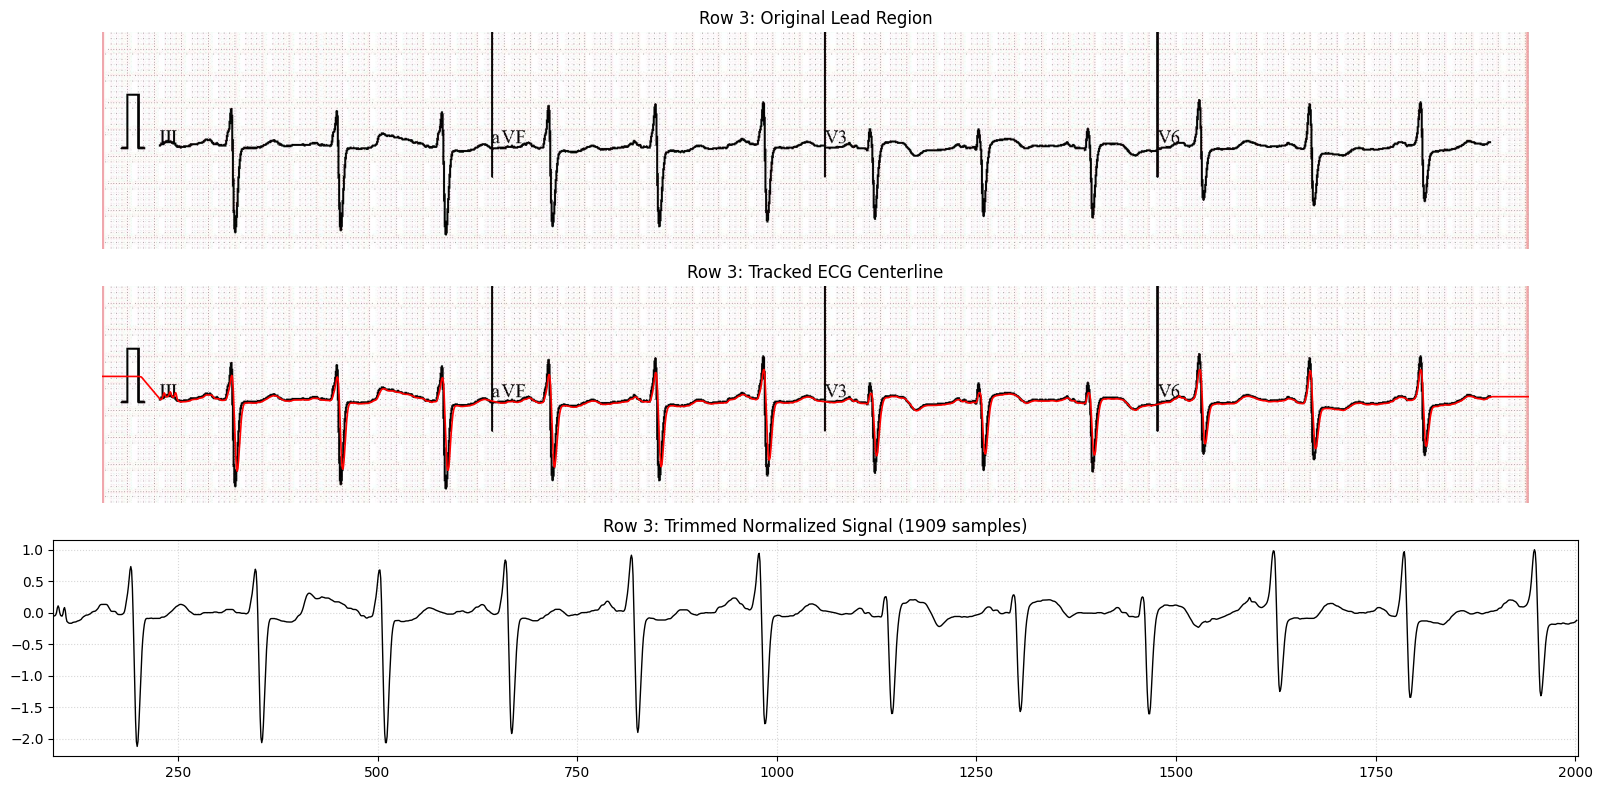

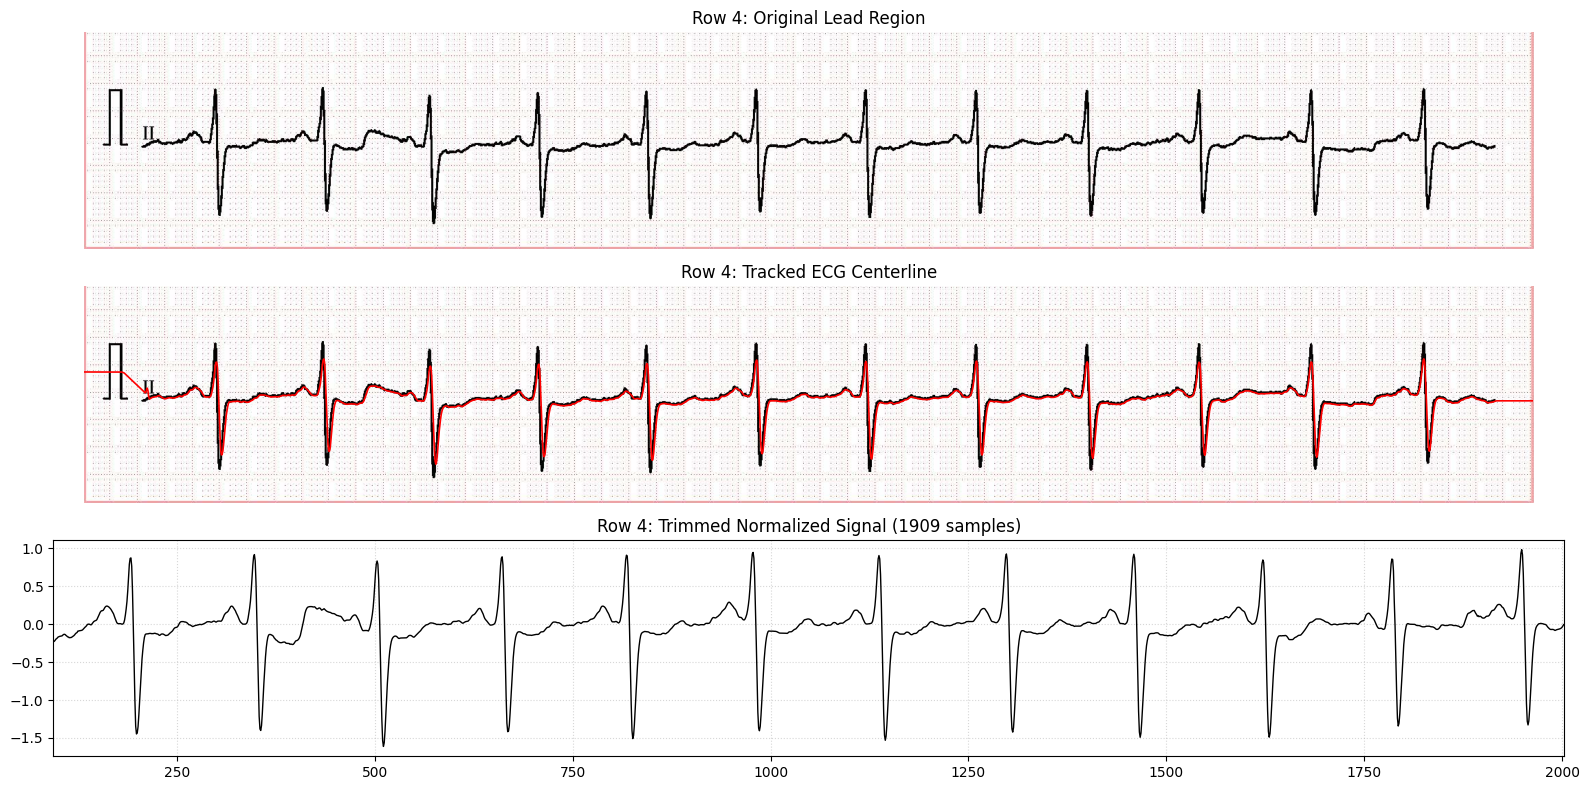

ECG rows processed: 4
Saved signals: /kaggle/working/ECG_Pipeline_Output/intermediate/trimmed_signals
✓ Cell 5 completed successfully.


In [5]:
# Cell 5: ECG Row Preparation, Wave Tracking, Trimming & Signal Extraction

def find_runs(arr: np.ndarray) -> list[tuple[int, int]]:
    arr = np.asarray(arr, dtype=bool)

    if arr.size == 0:
        return []

    padded = np.pad(arr.astype(np.int8), (1, 1))

    starts = np.where(np.diff(padded) == 1)[0]
    ends = np.where(np.diff(padded) == -1)[0]

    return list(zip(starts, ends))


def process_and_trim_ecg(
    row_img: np.ndarray,
    left_trim_pct: float = 0.045,
    right_trim_pct: float = 0.950,
) -> tuple[np.ndarray, np.ndarray, int, int]:

    if row_img is None or row_img.size == 0:
        raise ValueError("ECG row is empty.")

    gray = (
        cv2.cvtColor(row_img, cv2.COLOR_RGB2GRAY)
        if row_img.ndim == 3
        else row_img.astype(np.uint8)
    )

    if gray.ndim != 2:
        raise ValueError(
            f"Expected 2D grayscale ECG row, got shape {gray.shape}"
        )

    h, w = gray.shape

    if w < 50 or h < 10:
        raise ValueError(
            f"ECG row is too small for reliable tracking: {w} × {h}"
        )

    unique_values = np.unique(gray)

    if np.all(np.isin(unique_values, [0, 255])):
        mask = (gray == 0).astype(np.uint8)
    else:
        threshold = int(
            np.clip(
                np.percentile(gray, 1.0) + 50,
                80,
                150,
            )
        )

        mask = (gray <= threshold).astype(np.uint8)

    mask = cv2.morphologyEx(
        mask,
        cv2.MORPH_OPEN,
        cv2.getStructuringElement(
            cv2.MORPH_ELLIPSE,
            (2, 2),
        ),
    )

    blocked = np.zeros(w, dtype=bool)

    left_limit = min(
        w,
        max(1, int(w * 0.15)),
    )

    column_strength = mask[:, :left_limit].sum(axis=0)

    cal_threshold = max(
        12,
        int(h * 0.22),
    )

    cal_runs = find_runs(
        column_strength >= cal_threshold
    )

    cal_end = max(
        (
            end
            for start, end in cal_runs
            if start <= min(40, int(w * 0.05))
        ),
        default=0,
    )

    if cal_end > 0:
        blocked[
            :min(
                cal_end + 3,
                int(w * 0.10),
            )
        ] = True

    dense_threshold = max(
        20,
        int(h * 0.55),
    )

    dense_runs = find_runs(
        mask.sum(axis=0) >= dense_threshold
    )

    for start, end in dense_runs:
        start = max(0, start - 8)
        end = min(w, end + 8)
        blocked[start:end] = True

    segments = [
        (start, end)
        for start, end in find_runs(~blocked)
        if end - start >= 25
    ]

    traced_y = np.full(
        w,
        np.nan,
        dtype=np.float32,
    )

    support = np.zeros(
        w,
        dtype=bool,
    )

    y0 = int(h * 0.15)
    y1 = max(
        y0 + 1,
        int(h * 0.90),
    )

    max_vertical_jump = max(
        6.0,
        h * 0.12,
    )

    for start, end in segments:

        profile = (
            mask[:, start:end]
            .sum(axis=1)
            .astype(np.float32)
        )

        profile = cv2.GaussianBlur(
            profile.reshape(-1, 1),
            (1, 5),
            2.0,
        ).ravel()

        base_y = (
            y0
            + int(np.argmax(profile[y0:y1]))
        )

        current_y = float(base_y)

        for column in range(start, end):

            ink_rows = np.where(
                mask[:, column] > 0
            )[0]

            if ink_rows.size == 0:
                continue

            groups = np.split(
                ink_rows,
                np.where(
                    np.diff(ink_rows) != 1
                )[0] + 1,
            )

            valid_groups = [
                group
                for group in groups
                if group.size > 0
            ]

            if not valid_groups:
                continue

            cluster = min(
                valid_groups,
                key=lambda group: min(
                    abs(float(group[0]) - current_y),
                    abs(float(group[-1]) - current_y),
                ),
            )

            candidate_y = (
                float(cluster[0] + cluster[-1]) / 2.0
            )

            if (
                abs(candidate_y - current_y)
                <= max_vertical_jump
            ):
                current_y = candidate_y
                traced_y[column] = current_y
                support[column] = True

    valid = np.isfinite(traced_y)

    if valid.sum() < max(
        10,
        int(w * 0.05),
    ):
        raise ValueError(
            "Insufficient ECG waveform support detected "
            f"({valid.sum()} valid columns / {w})."
        )

    valid_x = np.flatnonzero(valid)
    valid_y = traced_y[valid]

    missing_x = np.flatnonzero(~valid)

    if missing_x.size > 0:
        traced_y[missing_x] = np.interp(
            missing_x,
            valid_x,
            valid_y,
        )

    smooth_y = cv2.GaussianBlur(
        traced_y.reshape(1, -1),
        (5, 1),
        0.8,
    ).ravel()

    med_win = max(
        3,
        int(w * 0.08),
    )

    if med_win % 2 == 0:
        med_win += 1

    max_valid_med_win = (
        w
        if w % 2 == 1
        else w - 1
    )

    med_win = min(
        med_win,
        max_valid_med_win,
    )

    if med_win < 3:
        raise ValueError(
            "ECG row is too short for baseline correction."
        )

    baseline = medfilt(
        smooth_y,
        kernel_size=med_win,
    )

    detrended = (
        smooth_y - baseline
    )

    low_percentile, high_percentile = np.percentile(
        detrended,
        [2, 98],
    )

    amplitude_range = (
        high_percentile - low_percentile
    )

    if amplitude_range < 1.0:
        raise ValueError(
            "ECG waveform amplitude is too small "
            "after baseline correction."
        )

    norm_sig = (
        -(
            detrended
            - np.median(detrended)
        )
        / max(
            amplitude_range / 2.0,
            1.0,
        )
    ).astype(np.float32)

    left_trim_pct = float(
        np.clip(left_trim_pct, 0.0, 0.50)
    )

    right_trim_pct = float(
        np.clip(right_trim_pct, 0.50, 1.0)
    )

    l_trim = int(
        w * left_trim_pct
    )

    r_trim = int(
        w * right_trim_pct
    )

    r_trim = max(
        l_trim + 1,
        min(r_trim, w),
    )

    trimmed_sig = norm_sig[
        l_trim:r_trim
    ]

    if trimmed_sig.size < 50:
        raise ValueError(
            "Trimmed ECG signal is too short: "
            f"{trimmed_sig.size} samples."
        )

    if not np.all(
        np.isfinite(trimmed_sig)
    ):
        raise ValueError(
            "Trimmed ECG signal contains "
            "NaN or infinite values."
        )

    return (
        smooth_y,
        trimmed_sig,
        l_trim,
        r_trim,
    )


if "ecg_roi" not in globals() or ecg_roi is None:
    raise RuntimeError(
        "ecg_roi is missing. Run Cell 4 first."
    )

if "clean_waveform" not in globals() or clean_waveform is None:
    raise RuntimeError(
        "clean_waveform is missing. Run Cell 4 first."
    )

if ecg_roi.size == 0 or clean_waveform.size == 0:
    raise RuntimeError(
        "ECG ROI or clean waveform is empty. "
        "Check Cell 4."
    )

roi_h, roi_w = ecg_roi.shape[:2]

if clean_waveform.shape[:2] != (roi_h, roi_w):
    raise ValueError(
        "ECG ROI and clean waveform dimensions do not match: "
        f"{ecg_roi.shape[:2]} vs {clean_waveform.shape[:2]}"
    )

NUM_ROWS = 4

if roi_h < NUM_ROWS * 20:
    raise ValueError(
        f"ECG ROI is too short to divide into {NUM_ROWS} rows."
    )

row_height = roi_h / NUM_ROWS

input_rows = []
original_rows = []

for index in range(NUM_ROWS):

    y_start = int(
        round(index * row_height)
    )

    y_end = int(
        round((index + 1) * row_height)
    )

    overlap = max(
        3,
        int(roi_h * 0.005),
    )

    if index > 0:
        y_start = max(
            0,
            y_start - overlap,
        )

    if index < NUM_ROWS - 1:
        y_end = min(
            roi_h,
            y_end + overlap,
        )

    original_rows.append(
        ecg_roi[y_start:y_end, :].copy()
    )

    input_rows.append(
        clean_waveform[y_start:y_end, :].copy()
    )

print(
    f"ECG ROI: {roi_w} × {roi_h} | "
    f"Rows prepared: {NUM_ROWS}"
)

extracted_results = []

for index, row_img in enumerate(
    input_rows,
    start=1,
):

    smooth_y, trimmed_sig, l_trim, r_trim = (
        process_and_trim_ecg(
            row_img,
            left_trim_pct=0.045,
            right_trim_pct=0.950,
        )
    )

    display_img = original_rows[index - 1]

    row_height_actual, row_width_actual = (
        row_img.shape[:2]
    )

    signal_path = (
        TRIMMED_DIR /
        f"row_{index}_trimmed_signal.npy"
    )

    np.save(
        signal_path,
        trimmed_sig,
    )

    extracted_results.append(
        {
            "row_index": index,
            "row_image": row_img,
            "interp_y": smooth_y,
            "trimmed_signal": trimmed_sig,
            "l_trim": l_trim,
            "r_trim": r_trim,
        }
    )

    fig, axes = plt.subplots(
        3,
        1,
        figsize=(16, 8),
    )

    axes[0].imshow(display_img)
    axes[0].set_title(
        f"Row {index}: Original Lead Region"
    )
    axes[0].axis("off")

    axes[1].imshow(display_img)
    axes[1].plot(
        np.arange(row_width_actual),
        smooth_y,
        color="red",
        linewidth=1.2,
    )
    axes[1].set_title(
        f"Row {index}: Tracked ECG Centerline"
    )
    axes[1].axis("off")

    axes[2].plot(
        np.arange(l_trim, r_trim),
        trimmed_sig,
        color="black",
        linewidth=1.0,
    )
    axes[2].set_title(
        f"Row {index}: Trimmed Normalized Signal "
        f"({len(trimmed_sig)} samples)"
    )
    axes[2].set_xlim(
        l_trim,
        r_trim,
    )
    axes[2].grid(
        True,
        linestyle=":",
        alpha=0.5,
    )

    plt.tight_layout()
    plt.show()

print(
    f"ECG rows processed: {len(extracted_results)}"
)

print(
    f"Saved signals: {TRIMMED_DIR}"
)

print("✓ Cell 5 completed successfully.")

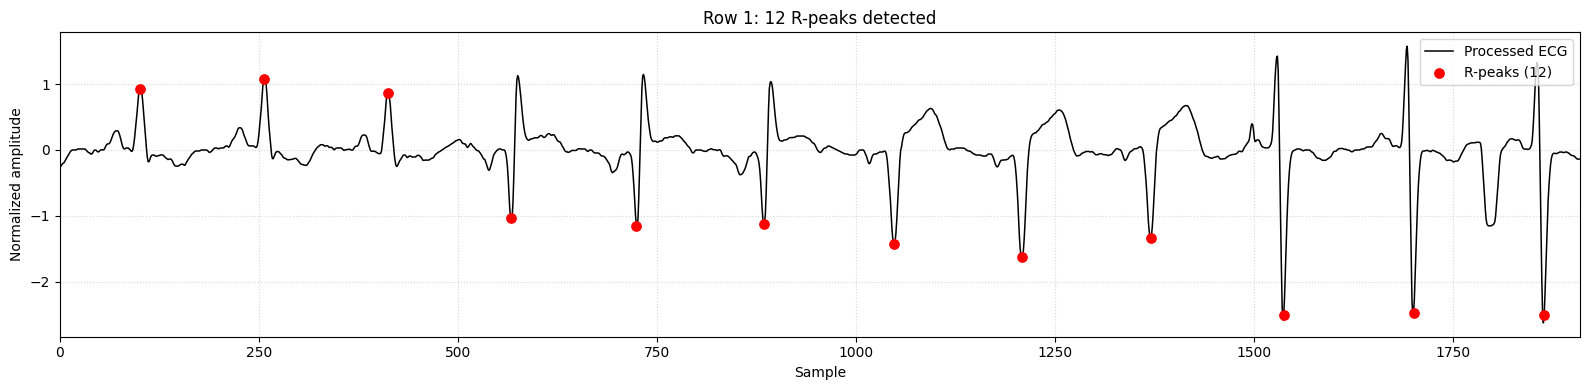

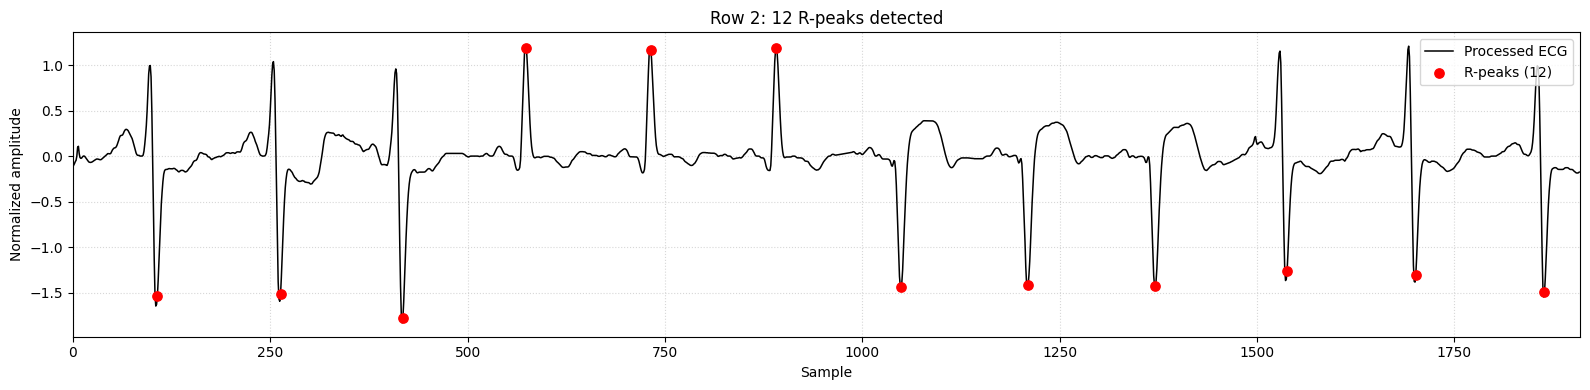

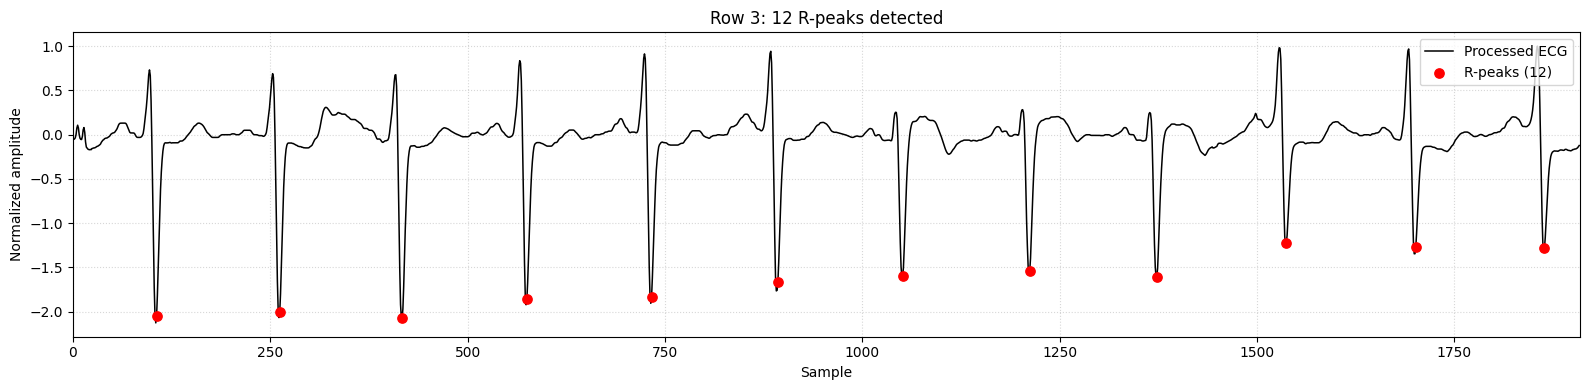

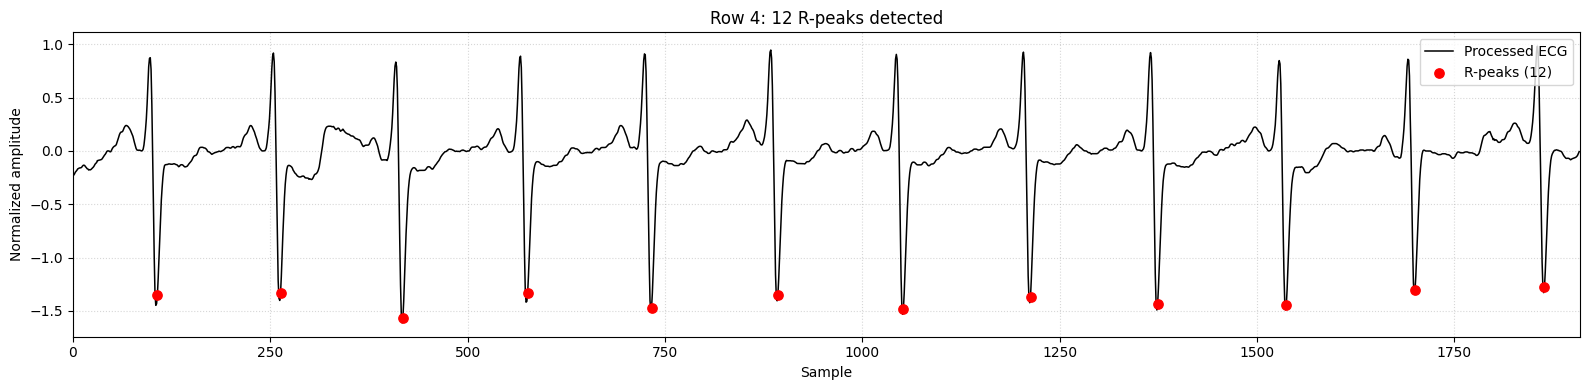

R-peak detection completed for 4 ECG rows.
Effective sampling rate: 257.1 Hz
Detected beats per row: [12, 12, 12, 12]
Total detected beats: 48
Peak files saved to: /kaggle/working/ECG_Pipeline_Output/intermediate/r_peaks
✓ Cell 6 completed successfully.


In [6]:
# Cell 6: Robust QRS-Focused R-Peak Detection

def detect_r_peaks(
    signal: np.ndarray,
    sampling_rate: float | None = None,
) -> np.ndarray:

    signal = np.asarray(
        signal,
        dtype=np.float32,
    ).ravel()

    if signal.size == 0:
        return np.array([], dtype=int)

    if not np.all(np.isfinite(signal)):
        raise ValueError(
            "ECG signal contains NaN or infinite values."
        )

    fs = float(
        sampling_rate
        if sampling_rate is not None
        else EFFECTIVE_FS
    )

    if fs <= 0:
        raise ValueError(
            f"Invalid sampling rate: {fs}"
        )

    n = len(signal)

    if n < max(100, int(fs * 0.8)):
        raise ValueError(
            f"ECG signal is too short for reliable R-peak detection: "
            f"{n} samples at {fs:.1f} Hz."
        )

    signal = signal - np.median(signal)

    signal_scale = np.percentile(
        signal,
        98,
    ) - np.percentile(
        signal,
        2,
    )

    if signal_scale < 1e-6:
        return np.array([], dtype=int)

    signal = signal / signal_scale

    low_cut = 5.0
    high_cut = min(
        18.0,
        fs * 0.45,
    )

    if high_cut <= low_cut:
        high_cut = min(
            15.0,
            fs * 0.40,
        )

    nyquist = fs / 2.0

    if high_cut >= nyquist:
        high_cut = nyquist * 0.90

    if low_cut >= high_cut:
        raise ValueError(
            f"Invalid QRS filter range: "
            f"{low_cut:.1f}-{high_cut:.1f} Hz "
            f"at {fs:.1f} Hz sampling."
        )

    b, a = butter(
        3,
        [
            low_cut / nyquist,
            high_cut / nyquist,
        ],
        btype="bandpass",
    )

    filtered = filtfilt(
        b,
        a,
        signal,
    )

    derivative = np.gradient(
        filtered
    )

    squared = derivative ** 2

    integration_window = max(
        5,
        int(round(0.12 * fs)),
    )

    if integration_window % 2 == 0:
        integration_window += 1

    integration_window = min(
        integration_window,
        n - 1 if (n - 1) % 2 == 1 else n - 2,
    )

    if integration_window < 3:
        integration_window = 3

    integration_kernel = np.ones(
        integration_window,
        dtype=np.float32,
    ) / integration_window

    envelope = np.convolve(
        squared,
        integration_kernel,
        mode="same",
    )

    envelope = gaussian_filter1d(
        envelope.astype(np.float32),
        sigma=max(
            1.0,
            0.025 * fs,
        ),
    )

    envelope = np.maximum(
        envelope,
        0,
    )

    q50 = float(
        np.percentile(
            envelope,
            50,
        )
    )

    q75 = float(
        np.percentile(
            envelope,
            75,
        )
    )

    q90 = float(
        np.percentile(
            envelope,
            90,
        )
    )

    q95 = float(
        np.percentile(
            envelope,
            95,
        )
    )

    noise_level = max(
        q50,
        1e-10,
    )

    signal_level = max(
        q90 - q50,
        1e-10,
    )

    prominence = max(
        noise_level * 0.35,
        signal_level * 0.20,
        1e-10,
    )

    min_distance = max(
        1,
        int(round(0.18 * fs)),
    )

    candidate_peaks, properties = find_peaks(
        envelope,
        distance=min_distance,
        prominence=prominence,
        height=max(
            q75,
            q50 + 0.15 * signal_level,
        ),
    )

    if len(candidate_peaks) == 0:
        relaxed_prominence = max(
            noise_level * 0.20,
            signal_level * 0.10,
            1e-10,
        )

        candidate_peaks, properties = find_peaks(
            envelope,
            distance=min_distance,
            prominence=relaxed_prominence,
            height=max(
                q75 * 0.90,
                q50 + 0.10 * signal_level,
            ),
        )

    if len(candidate_peaks) >= 2:

        rr_intervals = np.diff(
            candidate_peaks
        )

        median_rr = float(
            np.median(rr_intervals)
        )

        rescue_peaks = []

        for left_peak, right_peak in zip(
            candidate_peaks[:-1],
            candidate_peaks[1:],
        ):

            gap = right_peak - left_peak

            if gap <= 1.60 * median_rr:
                continue

            search_start = (
                left_peak
                + min_distance
            )

            search_end = (
                right_peak
                - min_distance
            )

            if search_end <= search_start:
                continue

            local_envelope = envelope[
                search_start:search_end
            ]

            if local_envelope.size == 0:
                continue

            local_index = int(
                np.argmax(local_envelope)
            )

            local_peak = (
                search_start
                + local_index
            )

            local_value = float(
                local_envelope[local_index]
            )

            if local_value >= max(
                q75 * 0.90,
                q50 + 0.20 * signal_level,
            ):
                rescue_peaks.append(
                    local_peak
                )

        if rescue_peaks:
            candidate_peaks = np.sort(
                np.unique(
                    np.concatenate(
                        [
                            candidate_peaks,
                            np.asarray(
                                rescue_peaks,
                                dtype=int,
                            ),
                        ]
                    )
                )
            )

    refinement_radius = max(
        3,
        int(round(0.06 * fs)),
    )

    refined_peaks = []

    for peak in candidate_peaks:

        left = max(
            0,
            int(peak - refinement_radius),
        )

        right = min(
            n,
            int(peak + refinement_radius + 1),
        )

        local_signal = filtered[
            left:right
        ]

        if local_signal.size == 0:
            continue

        local_index = int(
            np.argmax(
                np.abs(local_signal)
            )
        )

        refined_peak = (
            left
            + local_index
        )

        refined_peaks.append(
            refined_peak
        )

    if not refined_peaks:
        return np.array([], dtype=int)

    refined_peaks = np.sort(
        np.unique(
            np.asarray(
                refined_peaks,
                dtype=int,
            )
        )
    )

    if len(refined_peaks) > 1:

        rr = np.diff(
            refined_peaks
        )

        physiological_min = max(
            1,
            int(round(0.18 * fs)),
        )

        keep = np.ones(
            len(refined_peaks),
            dtype=bool,
        )

        for i in range(
            1,
            len(refined_peaks),
        ):

            if (
                refined_peaks[i]
                - refined_peaks[i - 1]
                < physiological_min
            ):

                previous_strength = abs(
                    filtered[
                        refined_peaks[i - 1]
                    ]
                )

                current_strength = abs(
                    filtered[
                        refined_peaks[i]
                    ]
                )

                if current_strength > previous_strength:
                    keep[i - 1] = False
                else:
                    keep[i] = False

        refined_peaks = refined_peaks[
            keep
        ]

    return refined_peaks


results = globals().get(
    "extracted_results",
    [],
)

if not results:
    raise RuntimeError(
        "No extracted ECG signals found. "
        "Run Cell 5 first."
    )

if "EFFECTIVE_FS" not in globals():
    raise RuntimeError(
        "EFFECTIVE_FS is missing. "
        "Run Cell 2 first."
    )

peak_counts = []

for result in results:

    trimmed_signal = result.get(
        "trimmed_signal"
    )

    row_index = result.get(
        "row_index",
        "Unknown",
    )

    if (
        trimmed_signal is None
        or len(trimmed_signal) == 0
    ):
        print(
            f"Row {row_index}: skipped because "
            "the signal is empty."
        )
        continue

    peaks = detect_r_peaks(
        trimmed_signal,
        sampling_rate=EFFECTIVE_FS,
    )

    result["r_peaks"] = peaks

    peak_path = (
        PEAK_DIR /
        f"row_{row_index}_r_peaks.npy"
    )

    np.save(
        peak_path,
        peaks,
    )

    peak_counts.append(
        len(peaks)
    )

    plt.figure(
        figsize=(16, 4)
    )

    plt.plot(
        trimmed_signal,
        color="black",
        linewidth=1.1,
        label="Processed ECG",
    )

    if len(peaks) > 0:

        plt.scatter(
            peaks,
            trimmed_signal[peaks],
            color="red",
            s=45,
            zorder=10,
            label=f"R-peaks ({len(peaks)})",
        )

    plt.title(
        f"Row {row_index}: "
        f"{len(peaks)} R-peaks detected"
    )

    plt.xlabel(
        "Sample"
    )

    plt.ylabel(
        "Normalized amplitude"
    )

    plt.xlim(
        0,
        len(trimmed_signal),
    )

    plt.grid(
        True,
        linestyle=":",
        alpha=0.5,
    )

    plt.legend(
        loc="upper right"
    )

    plt.tight_layout()
    plt.show()

print(
    f"R-peak detection completed for "
    f"{len(peak_counts)} ECG rows."
)

print(
    f"Effective sampling rate: "
    f"{EFFECTIVE_FS:.1f} Hz"
)

if peak_counts:
    print(
        f"Detected beats per row: "
        f"{peak_counts}"
    )

    print(
        f"Total detected beats: "
        f"{sum(peak_counts)}"
    )

print(
    f"Peak files saved to: {PEAK_DIR}"
)

print("✓ Cell 6 completed successfully.")

Cleared 0 old beat files.
Saving new segmented beats to:
/kaggle/working/ECG_Pipeline_Output/extracted_beats
Row 1: 12 peaks → 11 complete → 11 quality | Incomplete: 1 | Quality rejected: 0


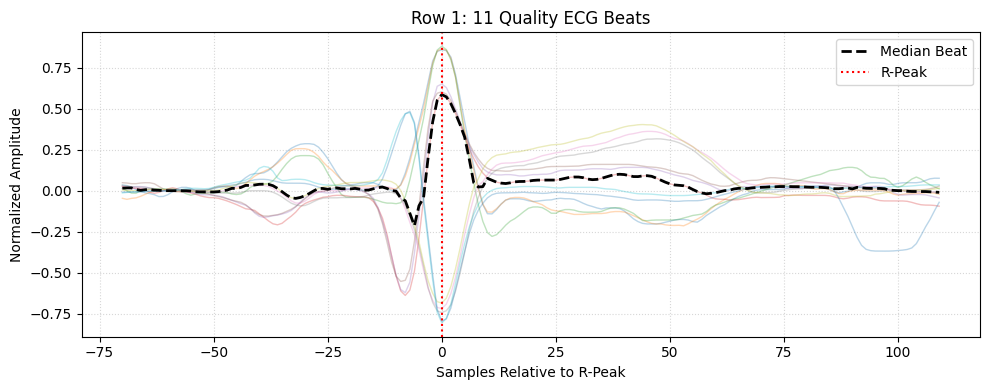

Row 2: 12 peaks → 11 complete → 11 quality | Incomplete: 1 | Quality rejected: 0


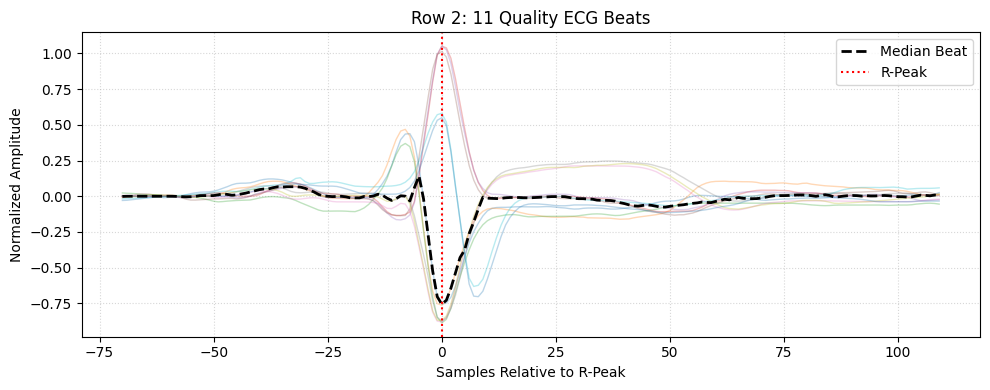

Row 3: 12 peaks → 11 complete → 11 quality | Incomplete: 1 | Quality rejected: 0


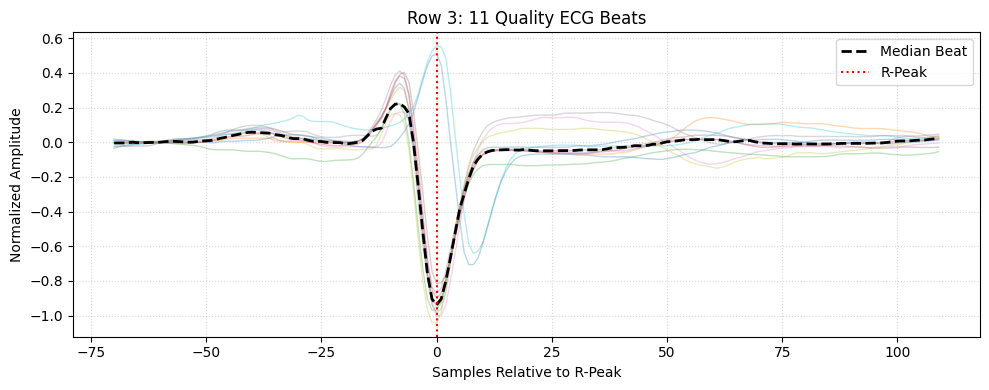

Row 4: 12 peaks → 11 complete → 11 quality | Incomplete: 1 | Quality rejected: 0


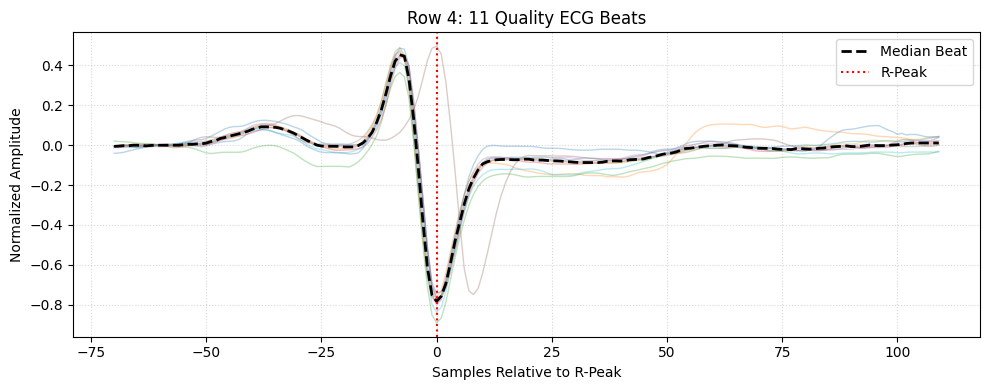


ECG BEAT EXTRACTION SUMMARY
Detected R-peaks       : 48
Complete beats         : 44
Quality beats          : 44
Incomplete beats       : 4
Quality-rejected beats : 0
Total unusable beats   : 4
Complete rate          : 91.67%
Quality retention      : 100.00%
Overall retention      : 91.67%
Beat length            : 180 samples
Total saved beats      : 44
Output directory       : /kaggle/working/ECG_Pipeline_Output/extracted_beats
✓ Cell 7 completed successfully.
✓ All quality-approved segmented beats are saved individually in one folder.


In [7]:
# ============================================================
# Cell 7: ECG Beat Extraction & Quality Control
#         + Save All Segmented Beats in One Folder
# ============================================================

SELECTED_LEAD = "ECG_Row_Signal"

time_axis = np.arange(
    -PRE_SAMPLES,
    POST_SAMPLES,
)

# ------------------------------------------------------------
# Output directories
# ------------------------------------------------------------

BEAT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

SINGLE_BEAT_DIR = Path(
    "/kaggle/working/ECG_Pipeline_Output/extracted_beats"
)

SINGLE_BEAT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ------------------------------------------------------------
# Quality-control parameters
# ------------------------------------------------------------

MIN_AMP_RATIO = 0.15
MAX_AMP_RATIO = 4.00

USE_RR_FILTER = False

RR_LOW_RATIO = 0.45
RR_HIGH_RATIO = 1.80


# ============================================================
# Function: Extract complete beats
# ============================================================

def extract_beats(
    sig: np.ndarray,
    peaks: np.ndarray,
    search_radius: int = 12,
) -> tuple[np.ndarray, np.ndarray]:

    sig = np.asarray(
        sig,
        dtype=np.float32,
    ).squeeze()

    peaks = np.asarray(
        peaks,
        dtype=int,
    ).ravel()

    if sig.ndim != 1:
        raise ValueError(
            f"Expected a 1D ECG signal, got shape {sig.shape}"
        )

    if sig.size == 0:
        return (
            np.empty(
                (0, BEAT_LENGTH),
                dtype=np.float32,
            ),
            np.array([], dtype=int),
        )

    if not np.all(np.isfinite(sig)):
        raise ValueError(
            "ECG signal contains NaN or infinite values."
        )

    if peaks.size == 0:
        return (
            np.empty(
                (0, BEAT_LENGTH),
                dtype=np.float32,
            ),
            np.array([], dtype=int),
        )

    beats = []
    valid_peaks = []

    for peak in peaks:

        peak = int(peak)

        if peak < 0 or peak >= len(sig):
            continue

        win_start = max(
            0,
            peak - search_radius,
        )

        win_end = min(
            len(sig),
            peak + search_radius + 1,
        )

        local_segment = sig[
            win_start:win_end
        ]

        if local_segment.size == 0:
            continue

        local_peak_offset = int(
            np.argmax(
                np.abs(
                    local_segment
                    - np.median(local_segment)
                )
            )
        )

        corrected_peak = (
            win_start
            + local_peak_offset
        )

        start = (
            corrected_peak
            - PRE_SAMPLES
        )

        end = (
            corrected_peak
            + POST_SAMPLES
        )

        if start < 0 or end > len(sig):
            continue

        beat = np.asarray(
            sig[start:end],
            dtype=np.float32,
        ).copy()

        if beat.size != BEAT_LENGTH:
            continue

        if not np.all(np.isfinite(beat)):
            continue

        # ----------------------------------------------------
        # Baseline correction
        # ----------------------------------------------------

        baseline_samples = max(
            5,
            int(PRE_SAMPLES * 0.30),
        )

        baseline = np.median(
            beat[:baseline_samples]
        )

        beat -= baseline

        # ----------------------------------------------------
        # Amplitude normalization
        # ----------------------------------------------------

        amplitude = (
            np.percentile(beat, 98)
            - np.percentile(beat, 2)
        )

        if amplitude < 1e-6:
            continue

        beat = beat / amplitude

        beats.append(
            beat.astype(np.float32)
        )

        valid_peaks.append(
            corrected_peak
        )

    if not beats:
        return (
            np.empty(
                (0, BEAT_LENGTH),
                dtype=np.float32,
            ),
            np.array([], dtype=int),
        )

    return (
        np.asarray(
            beats,
            dtype=np.float32,
        ),
        np.asarray(
            valid_peaks,
            dtype=int,
        ),
    )


# ============================================================
# Function: Quality filter
# ============================================================

def quality_filter(
    beats: np.ndarray,
    peaks: np.ndarray,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:

    n = len(beats)

    if n == 0:
        return (
            beats,
            peaks,
            np.array([], dtype=bool),
        )

    keep = np.ones(
        n,
        dtype=bool,
    )

    amplitudes = (
        np.percentile(
            beats,
            98,
            axis=1,
        )
        -
        np.percentile(
            beats,
            2,
            axis=1,
        )
    )

    median_amplitude = float(
        np.median(amplitudes)
    )

    if median_amplitude > 0:

        keep &= (
            amplitudes
            >= median_amplitude
            * MIN_AMP_RATIO
        )

        keep &= (
            amplitudes
            <= median_amplitude
            * MAX_AMP_RATIO
        )

    # --------------------------------------------------------
    # Optional RR interval filtering
    # --------------------------------------------------------

    if USE_RR_FILTER and n >= 3:

        rr = np.diff(peaks)

        if rr.size > 0:

            median_rr = float(
                np.median(rr)
            )

            for i in range(n):

                local_intervals = []

                if i > 0:
                    local_intervals.append(
                        rr[i - 1]
                    )

                if i < len(rr):
                    local_intervals.append(
                        rr[i]
                    )

                if local_intervals:

                    keep[i] &= any(
                        RR_LOW_RATIO
                        * median_rr
                        <= interval
                        <= RR_HIGH_RATIO
                        * median_rr
                        for interval in local_intervals
                    )

    valid_indices = np.flatnonzero(
        keep
    )

    return (
        beats[valid_indices],
        peaks[valid_indices],
        keep,
    )


# ============================================================
# Load extraction results
# ============================================================

results = globals().get(
    "extracted_results",
    [],
)

if not results:

    raise RuntimeError(
        "No extracted ECG results found. "
        "Run Cells 5 and 6 first."
    )


# ============================================================
# Clear old individual beat files
# ============================================================

old_beat_files = list(
    SINGLE_BEAT_DIR.glob("*.npy")
)

for old_file in old_beat_files:

    old_file.unlink()


print(
    f"Cleared {len(old_beat_files)} old beat files."
)

print(
    f"Saving new segmented beats to:\n"
    f"{SINGLE_BEAT_DIR}"
)


# ============================================================
# Counters
# ============================================================

total_peaks = 0
total_complete = 0
total_quality = 0
total_incomplete = 0
total_quality_rejected = 0

global_beat_index = 1


# ============================================================
# Process every ECG row
# ============================================================

for result in results:

    if "trimmed_signal" not in result:
        continue

    if "r_peaks" not in result:

        raise RuntimeError(
            f"Row {result.get('row_index', 'Unknown')} "
            "has no R-peaks. Run Cell 6 first."
        )

    signal = np.asarray(
        result["trimmed_signal"],
        dtype=np.float32,
    ).squeeze()

    peaks = np.asarray(
        result["r_peaks"],
        dtype=int,
    )

    row_index = result.get(
        "row_index",
        "Unknown",
    )

    if signal.ndim != 1:

        raise ValueError(
            f"Row {row_index}: expected 1D ECG signal, "
            f"got {signal.shape}."
        )


    # --------------------------------------------------------
    # Extract complete beats
    # --------------------------------------------------------

    complete_beats, complete_peaks = extract_beats(
        signal,
        peaks,
    )


    # --------------------------------------------------------
    # Quality filtering
    # --------------------------------------------------------

    good_beats, good_peaks, keep = quality_filter(
        complete_beats,
        complete_peaks,
    )


    incomplete_count = (
        len(peaks)
        -
        len(complete_beats)
    )


    quality_rejected_count = (
        len(complete_beats)
        -
        len(good_beats)
    )


    # --------------------------------------------------------
    # Store results
    # --------------------------------------------------------

    result["selected_lead"] = SELECTED_LEAD

    result["heartbeats"] = good_beats

    result["beat_peaks"] = good_peaks

    result["beat_time_axis"] = time_axis


    # --------------------------------------------------------
    # Update counters
    # --------------------------------------------------------

    total_peaks += len(peaks)

    total_complete += len(
        complete_beats
    )

    total_quality += len(
        good_beats
    )

    total_incomplete += (
        incomplete_count
    )

    total_quality_rejected += (
        quality_rejected_count
    )


    # --------------------------------------------------------
    # Print row summary
    # --------------------------------------------------------

    complete_rate = (
        len(complete_beats)
        /
        len(peaks)
        * 100
        if len(peaks)
        else 0
    )

    quality_rate = (
        len(good_beats)
        /
        len(complete_beats)
        * 100
        if len(complete_beats)
        else 0
    )


    print(
        f"Row {row_index}: "
        f"{len(peaks)} peaks → "
        f"{len(complete_beats)} complete → "
        f"{len(good_beats)} quality | "
        f"Incomplete: {incomplete_count} | "
        f"Quality rejected: {quality_rejected_count}"
    )


    # --------------------------------------------------------
    # Save row-level files
    # --------------------------------------------------------

    if len(good_beats) > 0:

        np.save(
            BEAT_DIR /
            f"row_{row_index}_heartbeats.npy",
            good_beats,
        )

        np.save(
            BEAT_DIR /
            f"row_{row_index}_beat_peaks.npy",
            good_peaks,
        )


    # ========================================================
    # Save EVERY beat separately into one common folder
    # ========================================================

    for local_index, beat in enumerate(
        good_beats
    ):

        peak_position = int(
            good_peaks[local_index]
        )


        beat_filename = (
            f"beat_{global_beat_index:06d}"
            f"_row_{row_index}"
            f"_peak_{peak_position}.npy"
        )


        np.save(
            SINGLE_BEAT_DIR /
            beat_filename,
            beat.astype(
                np.float32
            ),
        )


        global_beat_index += 1


    # --------------------------------------------------------
    # Plot quality beats
    # --------------------------------------------------------

    if len(good_beats) == 0:
        continue


    plt.figure(
        figsize=(10, 4)
    )


    for beat in good_beats:

        plt.plot(
            time_axis,
            beat,
            alpha=0.30,
            linewidth=1.0,
        )


    median_beat = np.median(
        good_beats,
        axis=0,
    )


    plt.plot(
        time_axis,
        median_beat,
        color="black",
        linewidth=2,
        linestyle="--",
        label="Median Beat",
    )


    plt.axvline(
        0,
        color="red",
        linestyle=":",
        label="R-Peak",
    )


    plt.title(
        f"Row {row_index}: "
        f"{len(good_beats)} Quality ECG Beats"
    )


    plt.xlabel(
        "Samples Relative to R-Peak"
    )


    plt.ylabel(
        "Normalized Amplitude"
    )


    plt.grid(
        True,
        linestyle=":",
        alpha=0.5,
    )


    plt.legend()

    plt.tight_layout()

    plt.show()


# ============================================================
# Overall statistics
# ============================================================

overall_complete_rate = (
    total_complete
    /
    total_peaks
    * 100
    if total_peaks
    else 0
)


overall_quality_rate = (
    total_quality
    /
    total_complete
    * 100
    if total_complete
    else 0
)


overall_retention = (
    total_quality
    /
    total_peaks
    * 100
    if total_peaks
    else 0
)


total_unusable = (
    total_incomplete
    +
    total_quality_rejected
)


# ============================================================
# Final summary
# ============================================================

print()

print("=" * 70)
print("ECG BEAT EXTRACTION SUMMARY")
print("=" * 70)

print(
    f"Detected R-peaks       : {total_peaks}"
)

print(
    f"Complete beats         : {total_complete}"
)

print(
    f"Quality beats          : {total_quality}"
)

print(
    f"Incomplete beats       : {total_incomplete}"
)

print(
    f"Quality-rejected beats : {total_quality_rejected}"
)

print(
    f"Total unusable beats   : {total_unusable}"
)

print(
    f"Complete rate          : "
    f"{overall_complete_rate:.2f}%"
)

print(
    f"Quality retention      : "
    f"{overall_quality_rate:.2f}%"
)

print(
    f"Overall retention      : "
    f"{overall_retention:.2f}%"
)

print(
    f"Beat length            : "
    f"{BEAT_LENGTH} samples"
)

print(
    f"Total saved beats      : "
    f"{global_beat_index - 1}"
)

print(
    f"Output directory       : "
    f"{SINGLE_BEAT_DIR}"
)

print("=" * 70)

print(
    "✓ Cell 7 completed successfully."
)

print(
    "✓ All quality-approved segmented beats "
    "are saved individually in one folder."
)

In [8]:
# Cell 8: ECG Dataset Loading, Augmentation & Five-Model Benchmark

SEED = 42
tf.keras.utils.set_random_seed(SEED)

GPUS = tf.config.list_physical_devices("GPU")

print("=" * 75)
print("ECG CLASSIFICATION HARDWARE")
print("=" * 75)
print("TensorFlow :", tf.__version__)
print("GPUs       :", len(GPUS))

for gpu in GPUS:
    try:
        tf.config.experimental.set_memory_growth(
            gpu,
            True
        )
    except RuntimeError:
        pass

if GPUS:
    tf.keras.mixed_precision.set_global_policy(
        "mixed_float16"
    )

    STRATEGY = tf.distribute.OneDeviceStrategy(
        device="/GPU:0"
    )

    print("Mixed precision : ENABLED")
    print("Training device : GPU:0")
    print("Strategy        : OneDeviceStrategy")

else:
    tf.keras.mixed_precision.set_global_policy(
        "float32"
    )

    STRATEGY = tf.distribute.get_strategy()

    print("Mixed precision : DISABLED")
    print("Training device : CPU")
    print("Strategy        : Default")

print(
    "Replicas        :",
    STRATEGY.num_replicas_in_sync
)

print("=" * 75)


DATASET_ROOT = Path(
    "/kaggle/input/datasets/ranesh2409/"
    "ecg-multi-classification"
)

if not DATASET_ROOT.exists():

    matches = list(
        Path("/kaggle/input").rglob(
            "*multi*class*"
        )
    )

    if matches:
        DATASET_ROOT = matches[0]

    else:
        raise FileNotFoundError(
            f"Dataset not found: {DATASET_ROOT}"
        )


TRAIN_DIR = DATASET_ROOT / "train"
VAL_DIR = DATASET_ROOT / "validation"
TEST_DIR = DATASET_ROOT / "test"

print("Dataset root:", DATASET_ROOT)
print("Train      :", TRAIN_DIR)
print("Validation :", VAL_DIR)
print("Test       :", TEST_DIR)


CLASS_NAMES = [
    "F",
    "N",
    "Q",
    "S",
    "V"
]

NUM_CLASSES = len(CLASS_NAMES)

IMG_SIZE = (
    300,
    300
)

BATCH_SIZE = 32

AUTOTUNE = tf.data.AUTOTUNE

print("\nClasses:", CLASS_NAMES)
print("Image size:", IMG_SIZE)
print("Global batch size:", BATCH_SIZE)


for split_dir in [
    TRAIN_DIR,
    VAL_DIR,
    TEST_DIR
]:

    if not split_dir.exists():

        raise FileNotFoundError(
            f"Missing directory: {split_dir}"
        )

    for class_name in CLASS_NAMES:

        class_dir = (
            split_dir /
            class_name
        )

        if not class_dir.exists():

            raise FileNotFoundError(
                f"Missing class directory: "
                f"{class_dir}"
            )

print("\n✓ Dataset folder structure verified")


def load_dataset(
    folder_path,
    shuffle
):

    return tf.keras.utils.image_dataset_from_directory(
        folder_path,
        labels="inferred",
        label_mode="int",
        class_names=CLASS_NAMES,
        color_mode="rgb",
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        seed=SEED if shuffle else None
    )


train_ds = load_dataset(
    TRAIN_DIR,
    shuffle=True
)

val_ds = load_dataset(
    VAL_DIR,
    shuffle=False
)

test_ds = load_dataset(
    TEST_DIR,
    shuffle=False
)


IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
}

train_counts = []

for class_name in CLASS_NAMES:

    class_dir = (
        TRAIN_DIR /
        class_name
    )

    count = sum(
        1
        for f in class_dir.iterdir()
        if (
            f.is_file()
            and
            f.suffix.lower()
            in IMAGE_EXTENSIONS
        )
    )

    train_counts.append(count)


train_labels = np.concatenate([
    np.full(
        count,
        class_index,
        dtype=np.int32
    )
    for class_index, count
    in enumerate(train_counts)
])


weights_arr = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_CLASSES),
    y=train_labels
)

class_weights = {
    i: float(weight)
    for i, weight
    in enumerate(weights_arr)
}


dist_df = pd.DataFrame({
    "Class": CLASS_NAMES,
    "Train Count": train_counts,
    "Class Weight": [
        round(
            class_weights[i],
            4
        )
        for i in range(NUM_CLASSES)
    ]
})

print("\n" + "=" * 75)
print("TRAINING DATA DISTRIBUTION")
print("=" * 75)

display(dist_df)


data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomRotation(
            factor=0.004,
            fill_mode="nearest"
        ),

        tf.keras.layers.RandomTranslation(
            height_factor=0.012,
            width_factor=0.012,
            fill_mode="nearest"
        ),

        tf.keras.layers.RandomZoom(
            height_factor=(-0.025, 0.025),
            width_factor=(-0.025, 0.025),
            fill_mode="nearest"
        ),

        tf.keras.layers.RandomContrast(
            factor=0.12
        ),
    ],
    name="ECG_Safe_Augmentation"
)


def augment_training(
    images,
    labels
):

    images = tf.cast(
        images,
        tf.float32
    )

    images = data_augmentation(
        images,
        training=True
    )

    return images, labels


train_ds_augmented = train_ds.map(
    augment_training,
    num_parallel_calls=AUTOTUNE
)

train_ds_augmented = (
    train_ds_augmented
    .prefetch(AUTOTUNE)
)

val_ds = (
    val_ds
    .prefetch(AUTOTUNE)
)

test_ds = (
    test_ds
    .prefetch(AUTOTUNE)
)


@tf.keras.utils.register_keras_serializable(
    package="ECG"
)
class ECGPreprocess(
    tf.keras.layers.Layer
):

    def __init__(
        self,
        mode,
        **kwargs
    ):

        super().__init__(
            **kwargs
        )

        self.mode = mode


    def call(
        self,
        inputs
    ):

        x = tf.cast(
            inputs,
            tf.float32
        )

        if self.mode == "resnet":

            x = x[..., ::-1]

            mean = tf.constant(
                [
                    103.939,
                    116.779,
                    123.68
                ],
                dtype=tf.float32
            )

            return x - mean


        if self.mode == "densenet":

            return (
                x / 127.5
                - 1.0
            )


        return x


    def get_config(self):

        config = super().get_config()

        config.update({
            "mode": self.mode
        })

        return config


MODEL_SPECS = {

    "EfficientNetB3": {
        "app":
            tf.keras.applications.EfficientNetB3
    },

    "ResNet50": {
        "app":
            tf.keras.applications.ResNet50
    },

    "DenseNet121": {
        "app":
            tf.keras.applications.DenseNet121
    },

    "MobileNetV3Large": {
        "app":
            tf.keras.applications.MobileNetV3Large
    },

    "ConvNeXtTiny": {
        "app":
            tf.keras.applications.ConvNeXtTiny,
        "preprocess": "builtin"
    }
}


def build_model(
    app_fn,
    model_key,
    name
):

    with STRATEGY.scope():

        base_model = app_fn(
            include_top=False,
            weights="imagenet",
            input_shape=(
                *IMG_SIZE,
                3
            )
        )

        base_model.trainable = False

        inputs = tf.keras.layers.Input(
            shape=(
                *IMG_SIZE,
                3
            ),
            name="ecg_input"
        )

        x = inputs

        preprocess_mode = {
            "ResNet50": "resnet",
            "DenseNet121": "densenet"
        }.get(model_key)

        if preprocess_mode:

            x = ECGPreprocess(
                preprocess_mode,
                name=(
                    f"{model_key}"
                    "_preprocess"
                )
            )(x)

        x = base_model(
            x,
            training=False
        )

        x = tf.keras.layers.Activation(
            "linear",
            name="gradcam_features"
        )(x)

        x = tf.keras.layers.GlobalAveragePooling2D(
            name="gap"
        )(x)

        x = tf.keras.layers.BatchNormalization(
            name="feature_bn"
        )(x)

        x = tf.keras.layers.Dropout(
            0.35,
            name="dropout_1"
        )(x)

        x = tf.keras.layers.Dense(
            256,
            activation="swish",
            kernel_regularizer=(
                tf.keras.regularizers.l2(
                    1e-5
                )
            ),
            name="projection"
        )(x)

        x = tf.keras.layers.Dropout(
            0.25,
            name="dropout_2"
        )(x)

        outputs = tf.keras.layers.Dense(
            NUM_CLASSES,
            activation="softmax",
            dtype="float32",
            name="classification"
        )(x)

        model = tf.keras.Model(
            inputs=inputs,
            outputs=outputs,
            name=name
        )

    return model


models = {}

for model_key, spec in MODEL_SPECS.items():

    models[model_key] = build_model(
        spec["app"],
        model_key,
        f"{model_key}_ECG"
    )


print("\n" + "=" * 75)
print("FIVE-MODEL ECG BENCHMARK INITIALIZED")
print("=" * 75)

for name, model in models.items():

    print(
        f"{name:<20} | "
        f"Parameters: "
        f"{model.count_params():,}"
    )

print("=" * 75)
print("✓ EfficientNetB3")
print("✓ ResNet50")
print("✓ DenseNet121")
print("✓ MobileNetV3Large")
print("✓ ConvNeXtTiny")
print("=" * 75)

ECG CLASSIFICATION HARDWARE
TensorFlow : 2.20.0
GPUs       : 2
Mixed precision : ENABLED
Training device : GPU:0
Strategy        : OneDeviceStrategy
Replicas        : 1
Dataset root: /kaggle/input/datasets/ranesh2409/ecg-multi-classification
Train      : /kaggle/input/datasets/ranesh2409/ecg-multi-classification/train
Validation : /kaggle/input/datasets/ranesh2409/ecg-multi-classification/validation
Test       : /kaggle/input/datasets/ranesh2409/ecg-multi-classification/test

Classes: ['F', 'N', 'Q', 'S', 'V']
Image size: (300, 300)
Global batch size: 32

✓ Dataset folder structure verified


I0000 00:00:1790664462.221162      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1790664462.224023      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 38222 files belonging to 5 classes.
Found 8190 files belonging to 5 classes.
Found 8191 files belonging to 5 classes.

TRAINING DATA DISTRIBUTION


,Class,Train Count,Class Weight
0,F,561,13.6264
1,N,25044,0.3052
2,Q,5613,1.3619
3,S,1945,3.9303
4,V,5059,1.5110


43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/applications/mobilenet_v3.py:519: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


12683000/12683000 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
111650432/111650432 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

FIVE-MODEL ECG BENCHMARK INITIALIZED
EfficientNetB3       | Parameters: 11,184,436
ResNet50             | Parameters: 24,121,733
DenseNet121          | Parameters: 7,305,285
MobileNetV3Large     | Parameters: 3,247,493
ConvNeXtTiny         | Parameters: 28,021,349
✓ EfficientNetB3
✓ ResNet50
✓ DenseNet121
✓ MobileNetV3Large
✓ ConvNeXtTiny


In [9]:
# Cell 9: Five-Model Single-Phase ECG Training

EPOCHS = 10
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
GRADIENT_CLIPNORM = 1.0

training_dataset = train_ds_augmented
validation_dataset = val_ds

trained_models = {}

print("=" * 75)
print("FIVE-MODEL ECG CLASSIFIER TRAINING")
print("=" * 75)
print(f"Models          : {len(models)}")
print(f"Epochs          : {EPOCHS} for every model")
print(f"Learning rate   : {LEARNING_RATE}")
print(f"Weight decay    : {WEIGHT_DECAY}")
print(f"Gradient clip   : {GRADIENT_CLIPNORM}")
print("=" * 75)


def make_metrics():

    return [
        tf.keras.metrics.SparseCategoricalAccuracy(
            name="accuracy"
        )
    ]


def find_backbone(model):

    nested_models = [
        layer
        for layer in model.layers
        if isinstance(
            layer,
            tf.keras.Model
        )
        and layer is not model
    ]

    if len(nested_models) != 1:

        raise RuntimeError(
            f"Expected exactly one backbone in "
            f"{model.name}, but found "
            f"{len(nested_models)}."
        )

    return nested_models[0]


for model_name, model in models.items():

    print("\n" + "=" * 75)
    print(
        f"TRAINING MODEL: {model_name}"
    )
    print("=" * 75)

    backbone = find_backbone(model)

    backbone.trainable = False

    for layer in backbone.layers:
        layer.trainable = False

    for layer in model.layers:

        if layer is backbone:
            layer.trainable = False

        elif isinstance(
            layer,
            tf.keras.layers.BatchNormalization
        ):
            layer.trainable = False

        else:
            layer.trainable = True

    print(
        f"Backbone: {backbone.name}"
    )

    print(
        f"Total parameters: "
        f"{model.count_params():,}"
    )

    print(
        f"Trainable tensors: "
        f"{len(model.trainable_variables)}"
    )

    with STRATEGY.scope():

        model.compile(
            optimizer=tf.keras.optimizers.AdamW(
                learning_rate=LEARNING_RATE,
                weight_decay=WEIGHT_DECAY,
                clipnorm=GRADIENT_CLIPNORM
            ),
            loss=tf.keras.losses.SparseCategoricalCrossentropy(),
            metrics=make_metrics()
        )

        history = model.fit(
            training_dataset,
            validation_data=validation_dataset,
            epochs=EPOCHS,
            class_weight=class_weights,
            verbose=1
        )

    trained_models[model_name] = model

    final_train_accuracy = (
        history.history["accuracy"][-1]
    )

    final_val_accuracy = (
        history.history["val_accuracy"][-1]
    )

    print(
        f"✓ {model_name} completed"
    )

    print(
        f"  Training accuracy   : "
        f"{final_train_accuracy:.4f}"
    )

    print(
        f"  Validation accuracy : "
        f"{final_val_accuracy:.4f}"
    )


print("\n" + "=" * 75)
print("ALL FIVE MODELS TRAINED")
print("=" * 75)

for model_name in trained_models:

    print(
        f"✓ {model_name}: "
        f"{EPOCHS} epoch"
    )

print("=" * 75)

FIVE-MODEL ECG CLASSIFIER TRAINING
Models          : 5
Epochs          : 10 for every model
Learning rate   : 0.001
Weight decay    : 0.0001
Gradient clip   : 1.0

TRAINING MODEL: EfficientNetB3
Backbone: efficientnetb3
Total parameters: 11,184,436
Trainable tensors: 4
Epoch 1/10
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 717s 569ms/step - accuracy: 0.8734 - loss: 0.5091 - val_accuracy: 0.9657 - val_loss: 0.1350
Epoch 2/10
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 624s 521ms/step - accuracy: 0.9230 - loss: 0.3413 - val_accuracy: 0.9705 - val_loss: 0.1104
Epoch 3/10
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 614s 512ms/step - accuracy: 0.9347 - loss: 0.3043 - val_accuracy: 0.9711 - val_loss: 0.1180
Epoch 4/10
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 621s 518ms/step - accuracy: 0.9447 - loss: 0.2877 - val_accuracy: 0.9755 - val_loss: 0.1094
Epoch 5/10
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 631s 527ms/step - accuracy: 0.9464 - loss: 0.2805 - val_accuracy: 0.9737 - val_loss: 0.1102
Epoch 6/10
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 635s 530ms/step - 

I0000 00:00:1790689604.204393      76 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1195/1195 ━━━━━━━━━━━━━━━━━━━━ 811s 640ms/step - accuracy: 0.8685 - loss: 0.5380 - val_accuracy: 0.9630 - val_loss: 0.1316
Epoch 2/10
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 663s 553ms/step - accuracy: 0.9267 - loss: 0.3604 - val_accuracy: 0.9684 - val_loss: 0.1232
Epoch 3/10
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 651s 543ms/step - accuracy: 0.9427 - loss: 0.3134 - val_accuracy: 0.9706 - val_loss: 0.1248
Epoch 4/10
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 648s 541ms/step - accuracy: 0.9482 - loss: 0.3016 - val_accuracy: 0.9775 - val_loss: 0.0934
Epoch 5/10
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 650s 543ms/step - accuracy: 0.9520 - loss: 0.2883 - val_accuracy: 0.9751 - val_loss: 0.0975
Epoch 6/10
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 644s 538ms/step - accuracy: 0.9548 - loss: 0.2887 - val_accuracy: 0.9779 - val_loss: 0.0979
Epoch 7/10
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 644s 537ms/step - accuracy: 0.9582 - loss: 0.2655 - val_accuracy: 0.9788 - val_loss: 0.0897
Epoch 8/10
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 647s 540ms/step - accuracy: 0.9

In [10]:
# Cell 10: Final Evaluation — Accuracy, Sensitivity, Specificity, Precision, Recall & F1

import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("=" * 85)
print("PREPARING EVALUATION DATASETS & GROUND TRUTH")
print("=" * 85)

# Load datasets with prefetching
train_eval_ds = load_dataset(TRAIN_DIR, shuffle=False).prefetch(tf.data.AUTOTUNE)
val_eval_ds = load_dataset(VAL_DIR, shuffle=False).prefetch(tf.data.AUTOTUNE)
test_eval_ds = load_dataset(TEST_DIR, shuffle=False).prefetch(tf.data.AUTOTUNE)

# Extract ground truth labels ONCE outside the model loop
print("Extracting ground truth labels...")
y_true_train = np.concatenate([y.numpy() for _, y in train_eval_ds], axis=0)
y_true_val = np.concatenate([y.numpy() for _, y in val_eval_ds], axis=0)
y_true_test = np.concatenate([y.numpy() for _, y in test_eval_ds], axis=0)

split_datasets = [
    ("Training set", train_eval_ds, y_true_train),
    ("Validation set", val_eval_ds, y_true_val),
    ("Test set", test_eval_ds, y_true_test),
]

records = []
test_predictions = {}
test_probabilities = {}
test_confusion_matrices = {}
test_class_metrics = {}

print("\n" + "=" * 85)
print("FIVE-MODEL ECG CLASSIFICATION EVALUATION")
print("=" * 85)

for model_name, model in trained_models.items():
    print(f"\nEvaluating {model_name}...")
    split_results = {}

    for split_name, dataset, y_true in split_datasets:
        # Optimized batched inference in a single call
        y_prob = model.predict(dataset, verbose=0)
        y_pred = np.argmax(y_prob, axis=1)

        # Confusion Matrix
        cm = confusion_matrix(
            y_true,
            y_pred,
            labels=np.arange(NUM_CLASSES)
        )

        sensitivity = []
        specificity = []

        # One-vs-Rest Per-Class Sensitivity and Specificity
        for class_index in range(NUM_CLASSES):
            tp = cm[class_index, class_index]
            fn = cm[class_index, :].sum() - tp
            fp = cm[:, class_index].sum() - tp
            tn = cm.sum() - tp - fn - fp

            sensitivity.append(tp / (tp + fn) if (tp + fn) > 0 else 0.0)
            specificity.append(tn / (tn + fp) if (tn + fp) > 0 else 0.0)

        # Multi-class ROC-AUC
        try:
            auc = roc_auc_score(
                y_true,
                y_prob,
                multi_class="ovr",
                average="macro",
                labels=np.arange(NUM_CLASSES)
            )
        except ValueError:
            auc = np.nan

        # Metric Collection
        split_results[split_name] = {
            "Accuracy": accuracy_score(y_true, y_pred),
            "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
            "Sensitivity": np.mean(sensitivity),
            "Specificity": np.mean(specificity),
            "Precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
            "Recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
            "F1": f1_score(y_true, y_pred, average="macro", zero_division=0),
            "ROC-AUC": auc,
        }

        # Store test-specific data for detailed displays
        if split_name == "Test set":
            test_predictions[model_name] = (y_true, y_pred)
            test_probabilities[model_name] = y_prob
            test_confusion_matrices[model_name] = cm
            test_class_metrics[model_name] = {
                "Sensitivity": np.array(sensitivity),
                "Specificity": np.array(specificity)
            }

    records.append({
        "Algorithm": model_name,
        **{
            (split, metric): value
            for split, values in split_results.items()
            for metric, value in values.items()
        }
    })

    print(f"✓ {model_name} evaluation completed")


# -------------------------------------------------------------------------
# DISPLAY RESULTS
# -------------------------------------------------------------------------

df_results = pd.DataFrame(records).set_index("Algorithm")
df_results.columns = pd.MultiIndex.from_tuples(df_results.columns)

df_formatted = df_results.map(
    lambda value: f"{value:.3f}" if pd.notna(value) else "N/A"
)

print("\n" + "=" * 105)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 105)
display(df_formatted)


print("\n" + "=" * 105)
print("TEST-SET PERFORMANCE")
print("=" * 105)

test_metrics = [
    "Accuracy",
    "Balanced Accuracy",
    "Sensitivity",
    "Specificity",
    "Precision",
    "Recall",
    "F1",
    "ROC-AUC",
]

test_results = df_results[[("Test set", metric) for metric in test_metrics]]
test_results.columns = test_metrics

display(test_results.style.format("{:.3f}"))


print("\n" + "=" * 105)
print("TEST-SET CLASS-WISE SENSITIVITY & SPECIFICITY")
print("=" * 105)

for model_name in trained_models:
    class_metrics = pd.DataFrame({
        "Class": CLASS_NAMES,
        "Sensitivity": test_class_metrics[model_name]["Sensitivity"],
        "Specificity": test_class_metrics[model_name]["Specificity"],
    })

    print(f"\n{model_name}")
    display(
        class_metrics.style.format({
            "Sensitivity": "{:.3f}",
            "Specificity": "{:.3f}",
        })
    )


print("\n" + "=" * 105)
print("TEST-SET CONFUSION MATRICES")
print("=" * 105)

for model_name, cm in test_confusion_matrices.items():
    print(f"\n{model_name}")
    cm_df = pd.DataFrame(
        cm,
        index=CLASS_NAMES,
        columns=CLASS_NAMES
    )
    cm_df.index.name = "Actual"
    cm_df.columns.name = "Predicted"

    display(cm_df)

PREPARING EVALUATION DATASETS & GROUND TRUTH
Found 38222 files belonging to 5 classes.
Found 8190 files belonging to 5 classes.
Found 8191 files belonging to 5 classes.
Extracting ground truth labels...

FIVE-MODEL ECG CLASSIFICATION EVALUATION

Evaluating EfficientNetB3...
✓ EfficientNetB3 evaluation completed

Evaluating ResNet50...
✓ ResNet50 evaluation completed

Evaluating DenseNet121...
✓ DenseNet121 evaluation completed

Evaluating MobileNetV3Large...
✓ MobileNetV3Large evaluation completed

Evaluating ConvNeXtTiny...
✓ ConvNeXtTiny evaluation completed

MODEL PERFORMANCE COMPARISON


Training set                                            \
                     Accuracy Balanced Accuracy Sensitivity Specificity   
Algorithm                                                                 
EfficientNetB3          0.981             0.940       0.940       0.994   
ResNet50                0.981             0.907       0.907       0.993   
DenseNet121             0.970             0.858       0.858       0.990   
MobileNetV3Large        0.976             0.898       0.898       0.991   
ConvNeXtTiny            0.980             0.919       0.919       0.991   

                                                 Validation set  \
                 Precision Recall     F1 ROC-AUC       Accuracy   
Algorithm                                                         
EfficientNetB3       0.949  0.940  0.944   0.997          0.978   
ResNet50             0.973  0.907  0.931   0.997          0.979   
DenseNet121          0.963  0.858  0.881   0.991          0.968   
MobileNetV3Large     0.973  0.898  0.924   0.995          0.976   
ConvNeXtTiny         0.961  0.919  0.938   0.997          0.979   

                                    ...                Test set  \
                 Balanced Accuracy  ...     F1 ROC-AUC Accuracy   
Algorithm                           ...                           
EfficientNetB3               0.926  ...  0.933   0.993    0.983   
ResNet50                     0.898  ...  0.922   0.993    0.982   
DenseNet121                  0.852  ...  0.873   0.988    0.972   
MobileNetV3Large             0.890  ...  0.917   0.990    0.979   
ConvNeXtTiny                 0.904  ...  0.930   0.996    0.982   

                                                                             \
                 Balanced Accuracy Sensitivity Specificity Precision Recall   
Algorithm                                                                     
EfficientNetB3               0.938       0.938       0.994     0.949  0.938   
ResNet50                     0.898       0.898       0.992     0.979  0.898   
DenseNet121                  0.857       0.857       0.990     0.951  0.857   
MobileNetV3Large             0.896       0.896       0.992     0.976  0.896   
ConvNeXtTiny                 0.912       0.912       0.991     0.973  0.912   

                                 
                     F1 ROC-AUC  
Algorithm                        
EfficientNetB3    0.943   0.995  
ResNet50          0.927   0.993  
DenseNet121       0.879   0.989  
MobileNetV3Large  0.924   0.994  
ConvNeXtTiny      0.938   0.997  

[5 rows x 24 columns]


TEST-SET PERFORMANCE


,Accuracy,Balanced Accuracy,Sensitivity,Specificity,Precision,Recall,F1,ROC-AUC
Algorithm,,,,,,,,
EfficientNetB3,0.983,0.938,0.938,0.994,0.949,0.938,0.943,0.995
ResNet50,0.982,0.898,0.898,0.992,0.979,0.898,0.927,0.993
DenseNet121,0.972,0.857,0.857,0.990,0.951,0.857,0.879,0.989
MobileNetV3Large,0.979,0.896,0.896,0.992,0.976,0.896,0.924,0.994
ConvNeXtTiny,0.982,0.912,0.912,0.991,0.973,0.912,0.938,0.997



TEST-SET CLASS-WISE SENSITIVITY & SPECIFICITY

EfficientNetB3


...

Predicted,F,N,Q,S,V
Actual,,,,,
F,41,56,0,0,23
N,2,5256,10,1,98
Q,1,5,1193,0,4
S,0,1,0,416,0
V,2,21,5,0,1056



MobileNetV3Large


Predicted,F,N,Q,S,V
Actual,,,,,
F,65,34,0,0,21
N,0,5303,2,0,62
Q,1,18,1183,0,1
S,0,1,0,416,0
V,1,29,1,0,1053



ConvNeXtTiny


Predicted,F,N,Q,S,V
Actual,,,,,
F,77,35,0,0,8
N,3,5343,1,0,20
Q,0,19,1182,0,2
S,0,2,0,415,0
V,4,56,1,0,1023


TEST-SET MODEL SELECTION
Selected model     : EfficientNetB3
Test Accuracy      : 0.9830
Test Sensitivity   : 0.9379
Test Specificity   : 0.9942
Test F1 Score      : 0.9430
Test ROC-AUC       : 0.9946


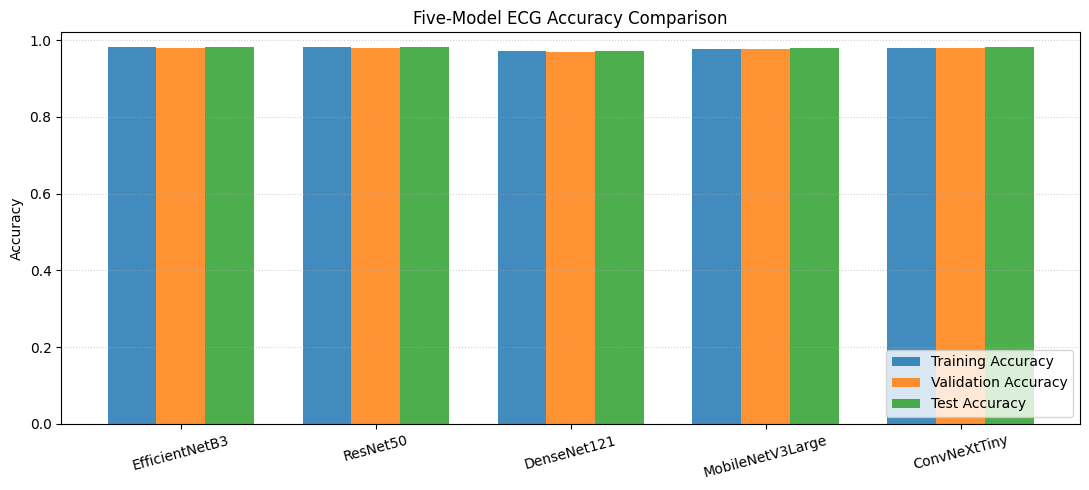

✓ Best model saved to: /kaggle/working/best_ecg_model_EfficientNetB3.keras
✓ Model size: 50.00 MB


In [11]:
# Cell 11: Performance Visualization, Test-Set Model Selection & Artifact Saving

df_sorted = df_results.sort_values(
    by=("Test set", "Accuracy"),
    ascending=False
)

best_model_name = df_sorted.index[0]

best_model = trained_models[
    best_model_name
]

best_accuracy = df_sorted.loc[
    best_model_name,
    ("Test set", "Accuracy")
]

best_sensitivity = df_sorted.loc[
    best_model_name,
    ("Test set", "Sensitivity")
]

best_specificity = df_sorted.loc[
    best_model_name,
    ("Test set", "Specificity")
]

best_f1 = df_sorted.loc[
    best_model_name,
    ("Test set", "F1")
]

best_auc = df_sorted.loc[
    best_model_name,
    ("Test set", "ROC-AUC")
]


print("=" * 75)
print("TEST-SET MODEL SELECTION")
print("=" * 75)

print(
    f"Selected model     : "
    f"{best_model_name}"
)

print(
    f"Test Accuracy      : "
    f"{best_accuracy:.4f}"
)

print(
    f"Test Sensitivity   : "
    f"{best_sensitivity:.4f}"
)

print(
    f"Test Specificity   : "
    f"{best_specificity:.4f}"
)

print(
    f"Test F1 Score      : "
    f"{best_f1:.4f}"
)

print(
    f"Test ROC-AUC       : "
    f"{best_auc:.4f}"
)

print("=" * 75)


models_list = df_results.index

x = np.arange(
    len(models_list)
)

width = 0.25


fig, ax = plt.subplots(
    figsize=(11, 5)
)

ax.bar(
    x - width,
    df_results[
        ("Training set", "Accuracy")
    ],
    width,
    label="Training Accuracy",
    alpha=0.85
)

ax.bar(
    x,
    df_results[
        ("Validation set", "Accuracy")
    ],
    width,
    label="Validation Accuracy",
    alpha=0.85
)

ax.bar(
    x + width,
    df_results[
        ("Test set", "Accuracy")
    ],
    width,
    label="Test Accuracy",
    alpha=0.85
)


ax.set_ylabel(
    "Accuracy"
)

ax.set_title(
    "Five-Model ECG Accuracy Comparison"
)

ax.set_xticks(x)

ax.set_xticklabels(
    models_list,
    rotation=15
)

ax.set_ylim(
    0.0,
    1.02
)

ax.legend(
    loc="lower right"
)

ax.grid(
    axis="y",
    linestyle=":",
    alpha=0.6
)

plt.tight_layout()
plt.show()


EXPORT_PATH = Path(
    "/kaggle/working/"
    f"best_ecg_model_{best_model_name}.keras"
)

best_model.save(
    EXPORT_PATH
)

print(
    f"✓ Best model saved to: "
    f"{EXPORT_PATH}"
)

print(
    f"✓ Model size: "
    f"{EXPORT_PATH.stat().st_size / (1024 ** 2):.2f} MB"
)

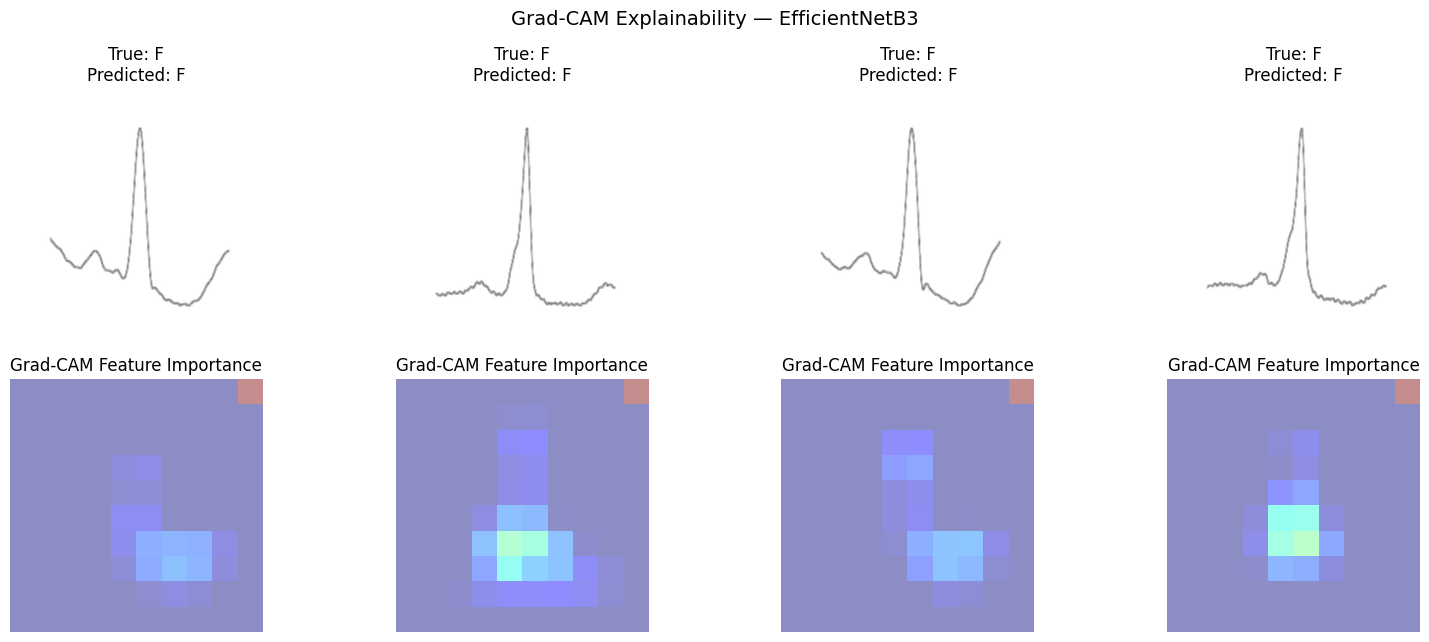

In [12]:
# Cell 12: Visual Explainability via Robust Grad-CAM

def generate_gradcam(
    img_tensor,
    model,
    layer_name="gradcam_features"
):

    if layer_name not in [
        layer.name
        for layer in model.layers
    ]:

        raise ValueError(
            f"Layer '{layer_name}' "
            f"was not found in "
            f"{model.name}."
        )

    feature_layer = model.get_layer(
        layer_name
    )

    grad_model = tf.keras.Model(
        inputs=model.inputs,
        outputs=[
            feature_layer.output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:

        conv_outputs, predictions = (
            grad_model(
                img_tensor,
                training=False
            )
        )

        pred_idx = tf.argmax(
            predictions[0]
        )

        class_channel = predictions[
            :,
            pred_idx
        ]

    grads = tape.gradient(
        class_channel,
        conv_outputs
    )

    if grads is None:

        raise RuntimeError(
            "Grad-CAM gradients are "
            "unavailable for the selected "
            "feature layer."
        )

    if len(conv_outputs.shape) != 4:

        raise ValueError(
            f"Grad-CAM requires a 4D "
            f"feature tensor, but received "
            f"shape {conv_outputs.shape}."
        )

    pooled_grads = tf.reduce_mean(
        grads,
        axis=(0, 1, 2)
    )

    conv_outputs = conv_outputs[0]

    heatmap = tf.reduce_sum(
        conv_outputs *
        pooled_grads,
        axis=-1
    )

    heatmap = tf.maximum(
        heatmap,
        0
    )

    max_value = tf.reduce_max(
        heatmap
    )

    heatmap = (
        heatmap /
        tf.maximum(
            max_value,
            1e-10
        )
    )

    return (
        heatmap.numpy(),
        int(pred_idx.numpy())
    )


target_layer = (
    "gradcam_features"
)

sample_batch = next(
    iter(test_eval_ds)
)

sample_imgs, sample_lbls = (
    sample_batch
)

num_samples = min(
    4,
    sample_imgs.shape[0]
)

sample_imgs = sample_imgs[
    :num_samples
]

sample_lbls = sample_lbls[
    :num_samples
].numpy()


fig, axes = plt.subplots(
    2,
    num_samples,
    figsize=(
        4 * num_samples,
        6.5
    )
)

if num_samples == 1:

    axes = np.expand_dims(
        axes,
        axis=1
    )


for i in range(num_samples):

    img_in = tf.expand_dims(
        sample_imgs[i],
        axis=0
    )

    true_label = CLASS_NAMES[
        int(sample_lbls[i])
    ]

    heatmap, pred_idx = (
        generate_gradcam(
            img_in,
            best_model,
            target_layer
        )
    )

    pred_label = CLASS_NAMES[
        pred_idx
    ]

    original_image = tf.cast(
        sample_imgs[i],
        tf.uint8
    ).numpy()

    axes[0, i].imshow(
        original_image
    )

    axes[0, i].set_title(
        f"True: {true_label}\n"
        f"Predicted: {pred_label}"
    )

    axes[0, i].axis("off")


    axes[1, i].imshow(
        original_image
    )

    axes[1, i].imshow(
        heatmap,
        cmap="jet",
        alpha=0.45
    )

    axes[1, i].set_title(
        "Grad-CAM Feature Importance"
    )

    axes[1, i].axis("off")


plt.suptitle(
    f"Grad-CAM Explainability — "
    f"{best_model_name}",
    fontsize=14
)

plt.tight_layout()
plt.show()

In [13]:
# ============================================================
# Cell 13: Classify ALL Segmented Beats Using Best Model
# ============================================================

from pathlib import Path

SEGMENTED_BEATS_DIR = Path(
    "/kaggle/working/ECG_Pipeline_Output/extracted_beats"
)

CLASS_LABELS_FULL = {
    "N": "Normal Beat",
    "S": "Supraventricular Ectopic Beat",
    "V": "Ventricular Ectopic Beat",
    "F": "Fusion Beat",
    "Q": "Unknown / Unclassifiable Beat",
}


# ------------------------------------------------------------
# 1. Find ALL segmented beat files
# ------------------------------------------------------------

beat_files = sorted(
    SEGMENTED_BEATS_DIR.glob("beat_*.npy")
)


if not beat_files:

    raise FileNotFoundError(
        f"No segmented beat files found in:\n"
        f"{SEGMENTED_BEATS_DIR}"
    )


print("=" * 75)
print("ECG SEGMENTED BEAT CLASSIFICATION")
print("=" * 75)

print(
    f"Segmented directory : {SEGMENTED_BEATS_DIR}"
)

print(
    f"Total beat files    : {len(beat_files)}"
)

print(
    f"Best model          : {best_model_name}"
)

print(
    f"Model input size    : {IMG_SIZE}"
)

print("=" * 75)


# ------------------------------------------------------------
# 2. Load ALL segmented beats
# ------------------------------------------------------------

raw_beats = []
valid_files = []


for beat_file in beat_files:

    beat = np.load(
        beat_file
    )

    beat = np.asarray(
        beat,
        dtype=np.float32
    ).squeeze()


    # Must be one-dimensional

    if beat.ndim != 1:

        print(
            f"Skipping {beat_file.name}: "
            f"invalid shape {beat.shape}"
        )

        continue


    # Must have correct length

    if len(beat) != BEAT_LENGTH:

        print(
            f"Skipping {beat_file.name}: "
            f"expected {BEAT_LENGTH}, "
            f"got {len(beat)}"
        )

        continue


    # Must contain valid numbers

    if not np.all(
        np.isfinite(beat)
    ):

        print(
            f"Skipping {beat_file.name}: "
            "contains NaN/Inf"
        )

        continue


    raw_beats.append(
        beat
    )

    valid_files.append(
        beat_file.name
    )


raw_beats = np.asarray(
    raw_beats,
    dtype=np.float32
)


total_beats = len(
    raw_beats
)


if total_beats == 0:

    raise RuntimeError(
        "No valid segmented beats available "
        "for classification."
    )


print(
    f"Valid beats         : {total_beats}"
)

print(
    f"Beat array shape     : {raw_beats.shape}"
)


# ============================================================
# 3. Convert every beat to model input image
# ============================================================

image_list = []


for beat in raw_beats:

    # --------------------------------------------------------
    # Normalize beat
    # --------------------------------------------------------

    beat_min = np.min(
        beat
    )

    beat_max = np.max(
        beat
    )


    if beat_max > beat_min:

        normalized_beat = (
            beat - beat_min
        ) / (
            beat_max - beat_min
        )

    else:

        normalized_beat = np.zeros_like(
            beat
        )


    # --------------------------------------------------------
    # Create ECG image
    # --------------------------------------------------------

    fig_temp, ax_temp = plt.subplots(
        figsize=(3.0, 3.0),
        dpi=100
    )


    ax_temp.plot(
        normalized_beat,
        linewidth=1.5
    )


    ax_temp.axis(
        "off"
    )


    fig_temp.subplots_adjust(
        left=0,
        right=1,
        bottom=0,
        top=1
    )


    fig_temp.canvas.draw()


    rgba_array = np.asarray(
        fig_temp.canvas.buffer_rgba()
    )


    img = rgba_array[:, :, :3]


    plt.close(
        fig_temp
    )


    # --------------------------------------------------------
    # Resize
    # --------------------------------------------------------

    img = cv2.resize(
        img,
        IMG_SIZE,
        interpolation=cv2.INTER_AREA
    )


    image_list.append(
        img
    )


# ------------------------------------------------------------
# Convert all images into one batch
# ------------------------------------------------------------

image_array = np.asarray(
    image_list,
    dtype=np.float32
)


print(
    f"Model input batch   : {image_array.shape}"
)


# ============================================================
# 4. Classification using BEST MODEL
# ============================================================

print()
print(
    "Running classification..."
)


predictions = best_model.predict(
    image_array,
    batch_size=32,
    verbose=1
)


# ------------------------------------------------------------
# Get predicted class
# ------------------------------------------------------------

pred_indices = np.argmax(
    predictions,
    axis=1
)


pred_classes = [
    CLASS_NAMES[index]
    for index in pred_indices
]


# ------------------------------------------------------------
# Get confidence
# ------------------------------------------------------------

confidences = (
    np.max(
        predictions,
        axis=1
    )
    * 100
)


print(
    "✓ Classification completed."
)


# ============================================================
# 5. Individual beat classification report
# ============================================================

df_beats = pd.DataFrame({

    "Beat File":
        valid_files,

    "Beat Index":
        np.arange(
            1,
            total_beats + 1
        ),

    "Class":
        pred_classes,

    "Description":
        [
            CLASS_LABELS_FULL.get(
                cls,
                "Unknown"
            )
            for cls in pred_classes
        ],

    "Confidence (%)":
        np.round(
            confidences,
            2
        )
})


# ============================================================
# 6. Classification summary
# ============================================================

counts = (
    df_beats["Class"]
    .value_counts()
    .reindex(
        CLASS_NAMES,
        fill_value=0
    )
)


summary_df = pd.DataFrame({

    "Class":
        CLASS_NAMES,

    "Description":
        [
            CLASS_LABELS_FULL.get(
                cls,
                "Unknown"
            )
            for cls in CLASS_NAMES
        ],

    "Beat Count":
        counts.values,

    "Percentage (%)":
        np.round(
            (
                counts.values
                /
                total_beats
            ) * 100,
            2
        )
})


# ============================================================
# 7. Display summary
# ============================================================

print()
print("=" * 75)
print("PATIENT ECG CLASSIFICATION SUMMARY")
print("=" * 75)

display(
    summary_df
)


# ============================================================
# 8. Display individual predictions
# ============================================================

print()
print("=" * 75)
print("INDIVIDUAL SEGMENTED BEAT CLASSIFICATIONS")
print("=" * 75)

display(
    df_beats
)

ECG SEGMENTED BEAT CLASSIFICATION
Segmented directory : /kaggle/working/ECG_Pipeline_Output/extracted_beats
Total beat files    : 44
Best model          : EfficientNetB3
Model input size    : (300, 300)
Valid beats         : 44
Beat array shape     : (44, 180)
Model input batch   : (44, 300, 300, 3)

Running classification...
2/2 ━━━━━━━━━━━━━━━━━━━━ 27s 23s/step
✓ Classification completed.

PATIENT ECG CLASSIFICATION SUMMARY


,Class,Description,Beat Count,Percentage (%)
0,F,Fusion Beat,9,20.45
1,N,Normal Beat,4,9.09
2,Q,Unknown / Unclassifiable Beat,0,0.00
3,S,Supraventricular Ectopic Beat,21,47.73
4,V,Ventricular Ectopic Beat,10,22.73



INDIVIDUAL SEGMENTED BEAT CLASSIFICATIONS


,Beat File,Beat Index,Class,Description,Confidence (%)
0,beat_000001_row_1_peak_101.npy,1,S,Supraventricular Ectopic Beat,68.800003
1,beat_000002_row_1_peak_257.npy,2,S,Supraventricular Ectopic Beat,99.720001
2,beat_000003_row_1_peak_412.npy,3,S,Supraventricular Ectopic Beat,90.610001
3,beat_000004_row_1_peak_575.npy,4,S,Supraventricular Ectopic Beat,87.839996
4,beat_000005_row_1_peak_733.npy,5,S,Supraventricular Ectopic Beat,60.000000
5,beat_000006_row_1_peak_893.npy,6,V,Ventricular Ectopic Beat,49.240002
6,beat_000007_row_1_peak_1048.npy,7,V,Ventricular Ectopic Beat,99.980003
7,beat_000008_row_1_peak_1208.npy,8,V,Ventricular Ectopic Beat,99.959999
8,beat_000009_row_1_peak_1370.npy,9,V,Ventricular Ectopic Beat,99.959999
9,beat_000010_row_1_peak_1536.npy,10,S,Supraventricular Ectopic Beat,54.939999


TEST SET ERROR ANALYSIS: 139 misclassified beats out of 8,191
Error rate: 1.70%


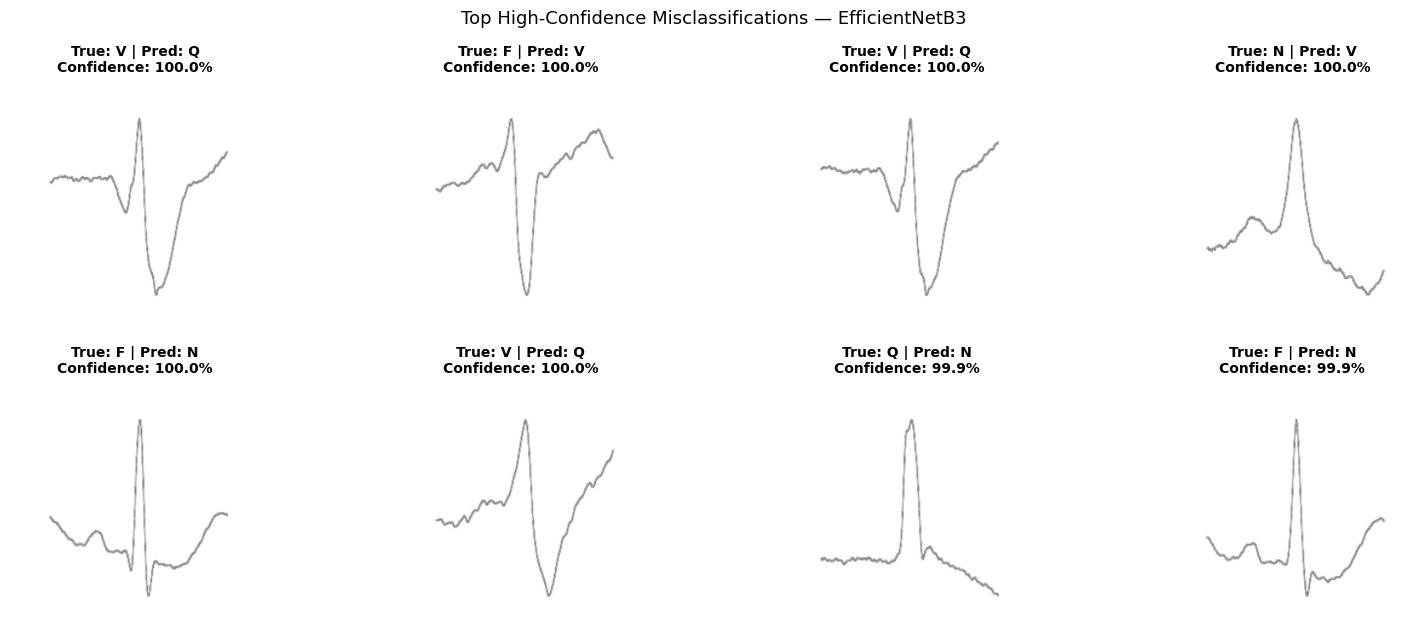


HIGH-CONFIDENCE ERROR TABLE


,Test Index,True Class,Predicted Class,Confidence (%)
0,8163,V,Q,100.00
1,100,F,V,99.99
2,7487,V,Q,99.98
3,3696,N,V,99.98
4,96,F,N,99.98
5,7840,V,Q,99.95
6,6473,Q,N,99.94
7,91,F,N,99.90


In [14]:
# Cell 14: High-Confidence Misclassification Inspection

y_true_ts, y_pred_ts = (
    test_predictions[
        best_model_name
    ]
)

test_probs = (
    test_probabilities[
        best_model_name
    ]
)


error_mask = (
    y_true_ts != y_pred_ts
)

error_indices = np.where(
    error_mask
)[0]

total_test_samples = len(
    y_true_ts
)

total_errors = len(
    error_indices
)

error_rate = (
    total_errors /
    total_test_samples
)


print("=" * 75)
print(
    f"TEST SET ERROR ANALYSIS: "
    f"{total_errors:,} misclassified "
    f"beats out of "
    f"{total_test_samples:,}"
)

print(
    f"Error rate: "
    f"{error_rate * 100:.2f}%"
)

print("=" * 75)


if total_errors > 0:

    error_confidences = (
        test_probs[
            error_indices,
            y_pred_ts[
                error_indices
            ]
        ]
    )


    ranking = np.argsort(
        error_confidences
    )[::-1]


    top_n = min(
        8,
        total_errors
    )


    selected_errors = (
        error_indices[
            ranking[:top_n]
        ]
    )


    test_images = []

    for images, labels in test_eval_ds:

        test_images.append(
            images.numpy()
        )


    test_images = np.concatenate(
        test_images,
        axis=0
    )


    fig, axes = plt.subplots(
        2,
        4,
        figsize=(16, 6.5)
    )

    axes_flat = axes.ravel()


    for plot_idx, error_index in enumerate(
        selected_errors
    ):

        true_index = int(
            y_true_ts[
                error_index
            ]
        )

        pred_index = int(
            y_pred_ts[
                error_index
            ]
        )

        confidence = (
            test_probs[
                error_index,
                pred_index
            ]
            * 100
        )


        true_class = (
            CLASS_NAMES[
                true_index
            ]
        )

        predicted_class = (
            CLASS_NAMES[
                pred_index
            ]
        )


        axes_flat[
            plot_idx
        ].imshow(
            test_images[
                error_index
            ].astype(
                "uint8"
            )
        )


        axes_flat[
            plot_idx
        ].set_title(
            f"True: {true_class} | "
            f"Pred: {predicted_class}\n"
            f"Confidence: "
            f"{confidence:.1f}%",
            fontsize=10,
            fontweight="bold"
        )


        axes_flat[
            plot_idx
        ].axis("off")


    for j in range(
        top_n,
        len(axes_flat)
    ):

        axes_flat[
            j
        ].axis("off")


    plt.suptitle(
        "Top High-Confidence "
        f"Misclassifications — "
        f"{best_model_name}",
        fontsize=13
    )

    plt.tight_layout()

    plt.show()


    error_summary = pd.DataFrame({
        "Test Index": selected_errors,

        "True Class": [
            CLASS_NAMES[
                int(
                    y_true_ts[i]
                )
            ]
            for i in selected_errors
        ],

        "Predicted Class": [
            CLASS_NAMES[
                int(
                    y_pred_ts[i]
                )
            ]
            for i in selected_errors
        ],

        "Confidence (%)": [
            round(
                float(
                    test_probs[
                        i,
                        y_pred_ts[i]
                    ]
                    * 100
                ),
                2
            )
            for i in selected_errors
        ]
    })


    print("\n" + "=" * 75)
    print(
        "HIGH-CONFIDENCE ERROR TABLE"
    )
    print("=" * 75)

    display(
        error_summary
    )


else:

    print(
        "✓ No misclassified test samples "
        "were found."
    )